In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

<font size ='5' color='black'>ch.12 데이터 시각화</font>
- 시각화 라이브러리 : matplotlib, seaborn, folium(지도 시각화)

- matplotlib : 파이썬에서 가장 기본적으로 사용되는 시각화 라이브러리. (판다스에서도 제공됨)
- seaborn : matplotlib 기반의 라이브러리. 다양한 색상, 테마, 차트 기능과 groupby 기능이 추가됨.

# 1. matplotlib
* api 참조 : [matplotlib api](https://matplotlib.org/stable/api/index.html)

## 1.1 import 및 기본 설정

### 한글 기본 폰트 설정

In [241]:
# 한글 기본 폰트 설정 방법 1
plt.style.use('ggplot')
plt.rc('font',family='Malgun Gothic') # Windows 한글 폰트 설정
plt.rc('axes', unicode_minus=False) # 한글 폰트 설정 시, 축의 음수 표현 오류 방지

In [349]:
# 한글 기본 폰트 설정 방법 2
from matplotlib.font_manager import FontProperties
font_path = r"C:\Users\Admin\Downloads\JMK체.ttf"
font_prop = FontProperties(fname=font_path, size=12)

In [237]:
# 한글 기본 폰트 설정 방법 3
# 1) pip install koreanize-matplotlib
# 2) import koreanize-matplotlib
# 3) 기본값 - NanumGothic으로 설정됨

In [336]:
#시작전 설정
import matplotlib.pyplot as plt
# 그래프를 코드 박스 아래에서 확인할 수 있게
%matplotlib inline
# 시각화한 그래프 해상도 높이기
%config InlineBackend.figure_format='retina'
# 한글 설정
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)
# 경고 메세지 안보이게
import warnings
warnings.filterwarnings(action='ignore')

## 1.2 그래프 그리기
- matplotlib으로 그래프를 그리기 위한 단계
    1) 데이터 준비
    2) 그래프 생성
    3) 함수로 그래프 그리기
    4) 그래프 커스터마이징
        - 색상이나 스타일 조정 : [color/style](https://wikidocs.net/92085)
    5) 그래프 출력 및 저장

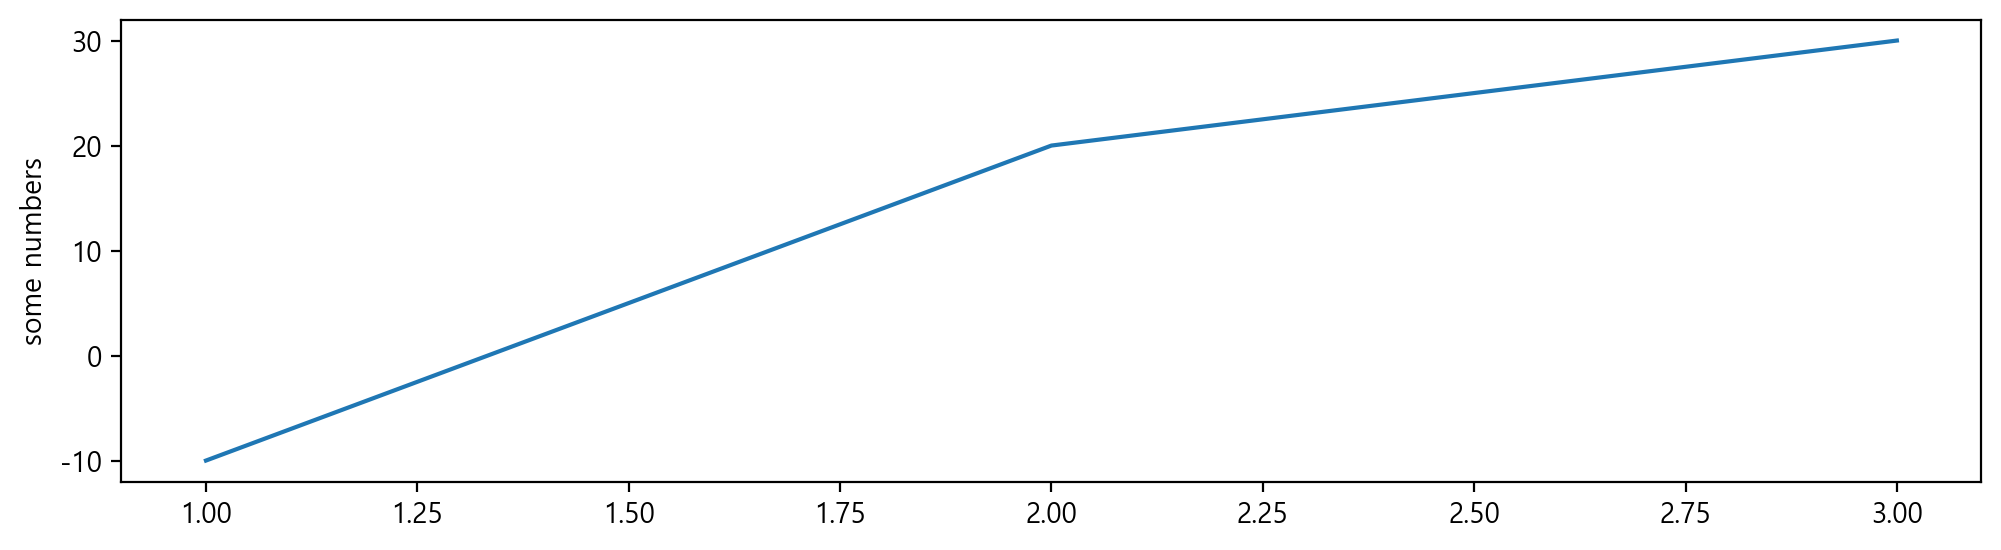

In [22]:
# 데이터 준비
x = [1,2,3]
y = [-10, 20, 30]

# 원하는 크기의 그래프 객체 생성
plt.figure(figsize=(12,3))

# 그래프 함수로 그리기
plt.plot(x,y)

# 그래프 커스터마이징
plt.ylabel('some numbers')

# 그래프 저장
plt.savefig('data/ch12_plot.png', bbox_inches='tight')

# 그래프 출력
plt.show()

## 1.3 그래프 영역 나누기

### 1) subplot()
- 서브 플롯 추가

In [26]:
import numpy as np
x = np.linspace(0, 9.9, 100)

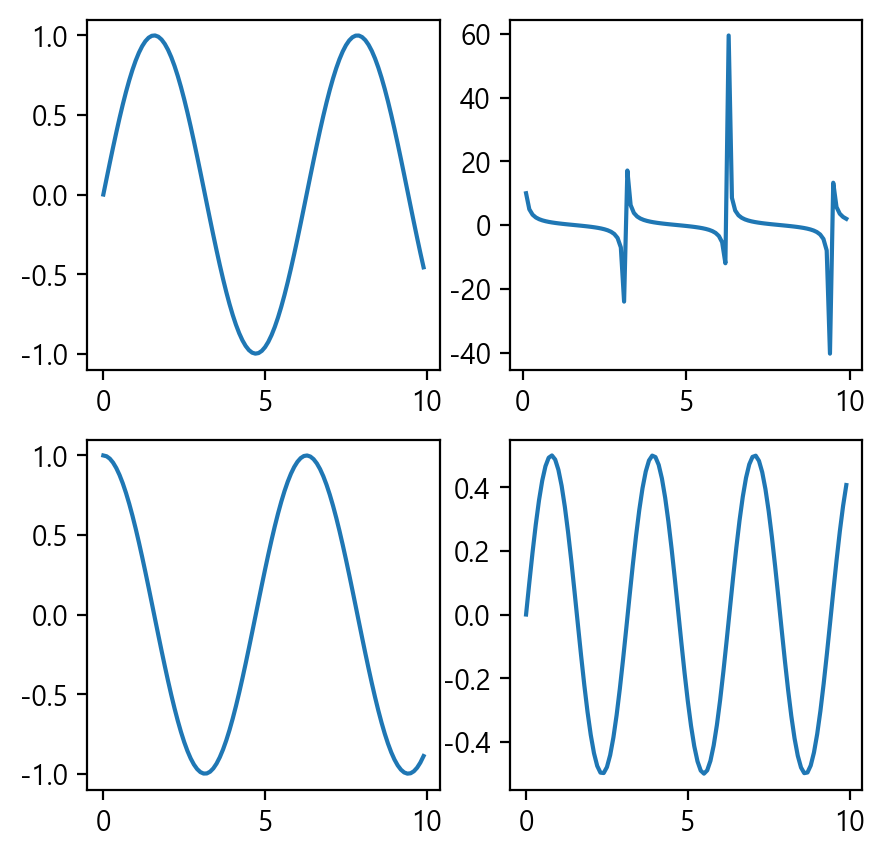

In [40]:
# plt.figure(figsize=(5, 5)) - 실행 중인 셀에 적용
plt.rcParams['figure.figsize'] = (5, 5) # 그래프 사이즈 고정(전체 셀에 적용)
# 2행 1열의 subplot 위치에 1번째 subplot을 '함수식'으로 그린다.
plt.subplot(2, 2, 1);plt.plot(x, np.sin(x))
plt.subplot(2, 2, 2);plt.plot(x, np.cos(x)/np.sin(x))
plt.subplot(2, 2, 3);plt.plot(x, np.cos(x))
plt.subplot(2, 2, 4);plt.plot(x,np.cos(x)*np.sin(x))
plt.show()

### 2) subplots()
- 서브 플롯 생성

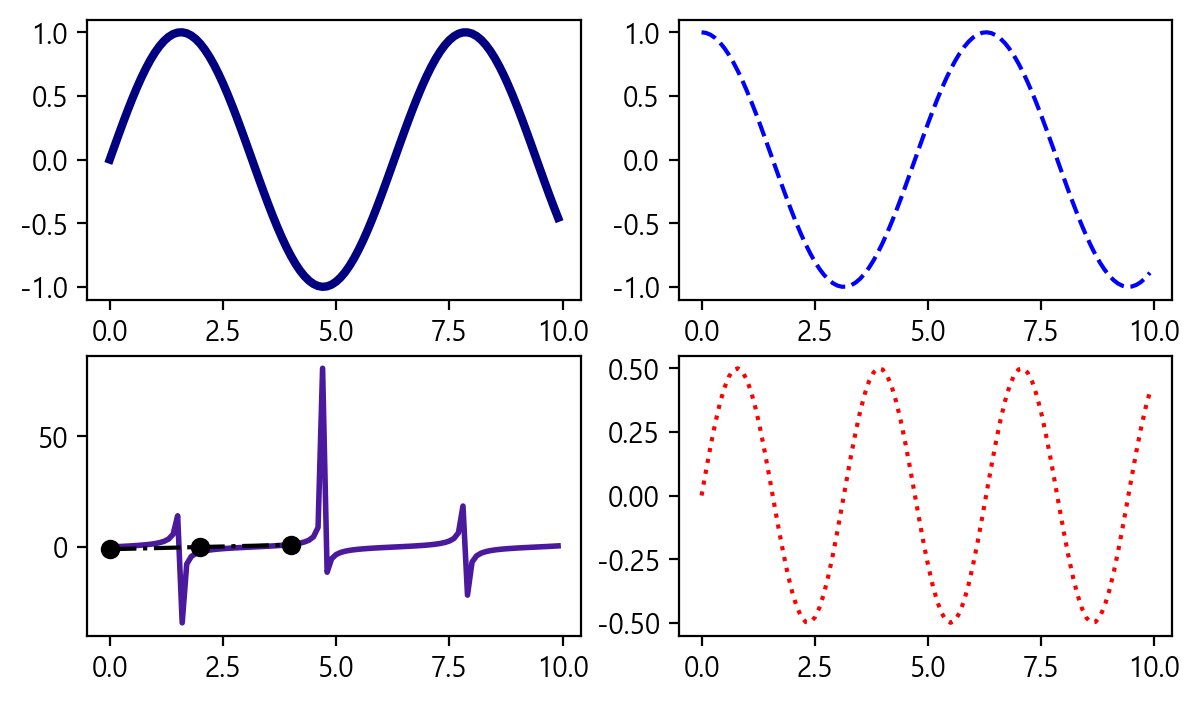

In [60]:
# subplots은 Figure size와 <Axes: >의 배열을 가짐
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(7,4))
axes[0,0].plot(x, np.sin(x), color = 'navy', linewidth=3)
axes[0,1].plot(x, np.cos(x), 'b--') # color = 'b', linestyle='--'
axes[1,0].plot(x, np.tan(x), '#4a199e', lw=2) # color = '#4a199e', linewidth = 2
axes[1,0].plot([0,2,4],[-1,0,1], 'ko-.') # color='k', marker='o', linestyle = '-.-'
axes[1,1].plot(x, np.sin(x)*np.cos(x),'r:') # color='k', linestyle = ':'
plt.show()

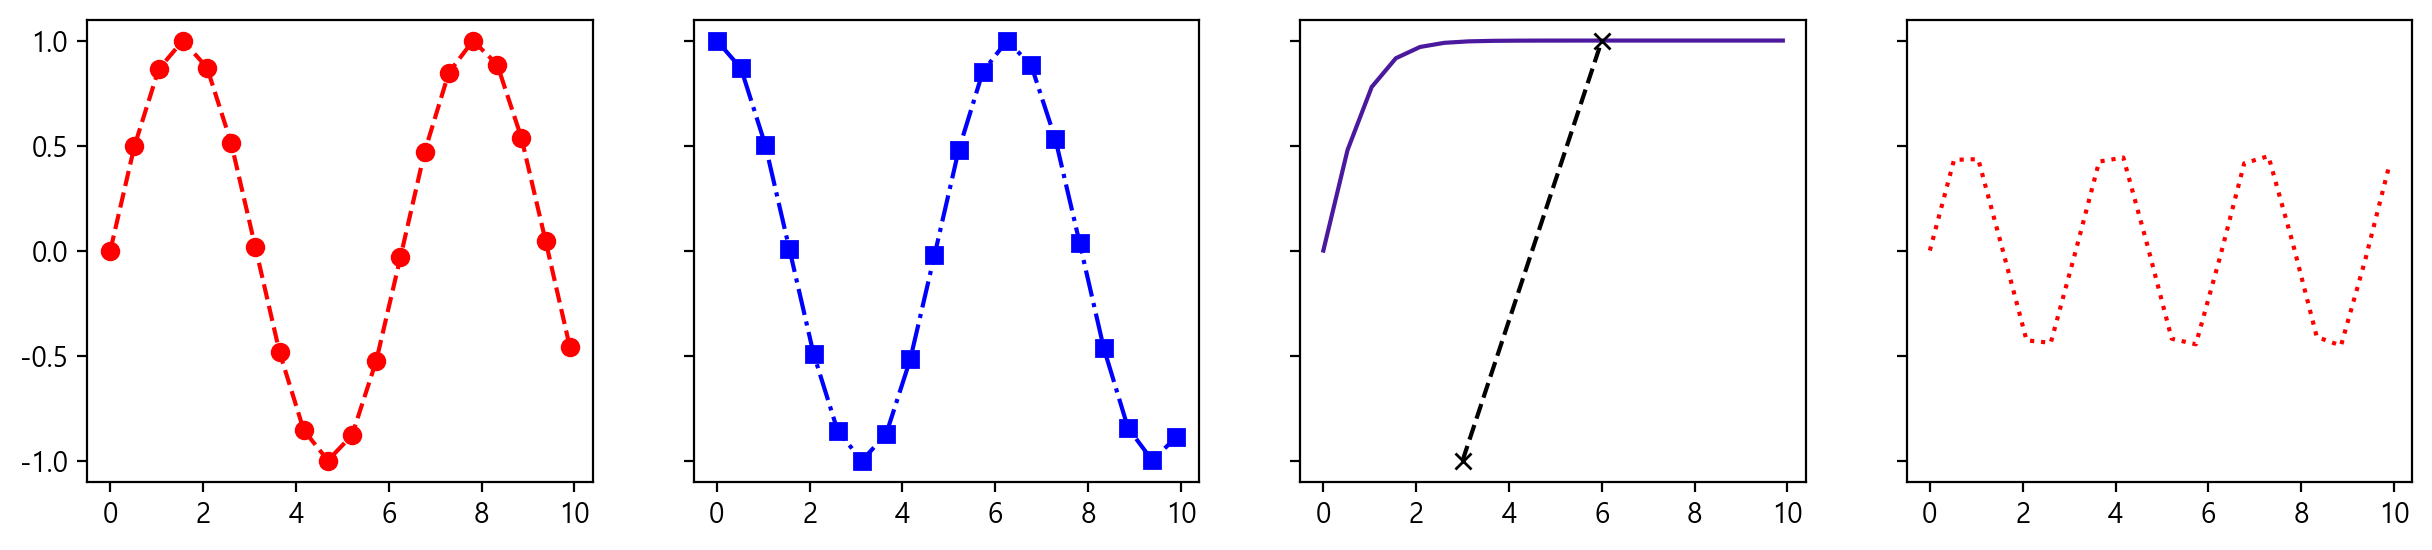

In [90]:
# for문 사용
x = np.linspace(0, 9.9, 20)

func_list = [np.sin,np.cos,np.tanh,lambda x:np.sin(x)*np.cos(x)]
fmt_lst = ['ro--', 'bs-.', '#4a199e', 'r:']

fig, axes = plt.subplots(1, 4, figsize=(15,3), sharey=True)
for i, ax in enumerate(axes.flat):
    ax.plot(x, func_list[i](x), fmt_lst[i])
    
axes[2].plot([3,6],[-1,1],'kx--')
plt.show()

## 1.4 다양한 그래프 그리기

### 1) pyplot
- [pyplot functions](https://matplotlib.org/3.5.0/api/_as_gen/matplotlib.pyplot.html)

### 2) matplotlib.pyplot.plot()
- 선그래프
* c, color : [색상](https://wikidocs.net/92085)
* marker : o, ^, x, s
* linestyle : -, --, :, -.

### 3) pandas.DataFrame.plot()
- plt.plot(x, y, fmt)
- df. plot(x = None, y = None, kind = 'line', figsize = None, title = None, grid = None, xlim, ylim...)
    * kind = line(기본값), scatter(점), bar(막대), barh(가로막대), box(박스), density=kde(밀도추정), hist(빈도)...
    * figsize : 그래프 크기 ; tuple (inch)
    * xlim, ylim : 축의 범위 ; list/tuple

In [91]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris.sample(2)

,sepal_length,sepal_width,petal_length,petal_width,species
87,6.3,2.3,4.4,1.3,versicolor
119,6.0,2.2,5.0,1.5,virginica


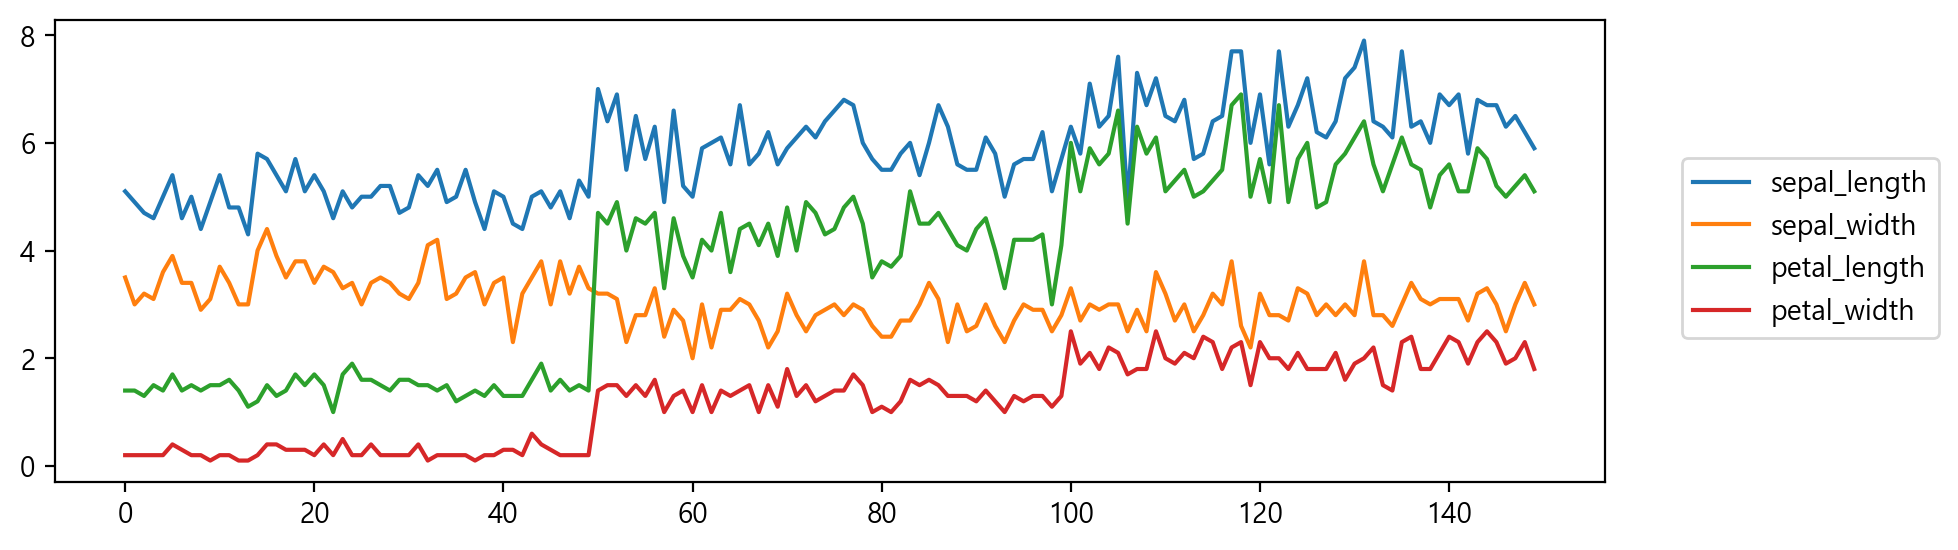

In [101]:
# 지양하는 방식 plt.plot
plt.rcParams['figure.figsize'] = [10,3]
plt.plot(iris.index, iris.iloc[:,:-1])
plt.legend(iris.columns[:-1],bbox_to_anchor=(1.05, 0.7), loc=2, borderaxespad=0.) # 범례 위치 이동

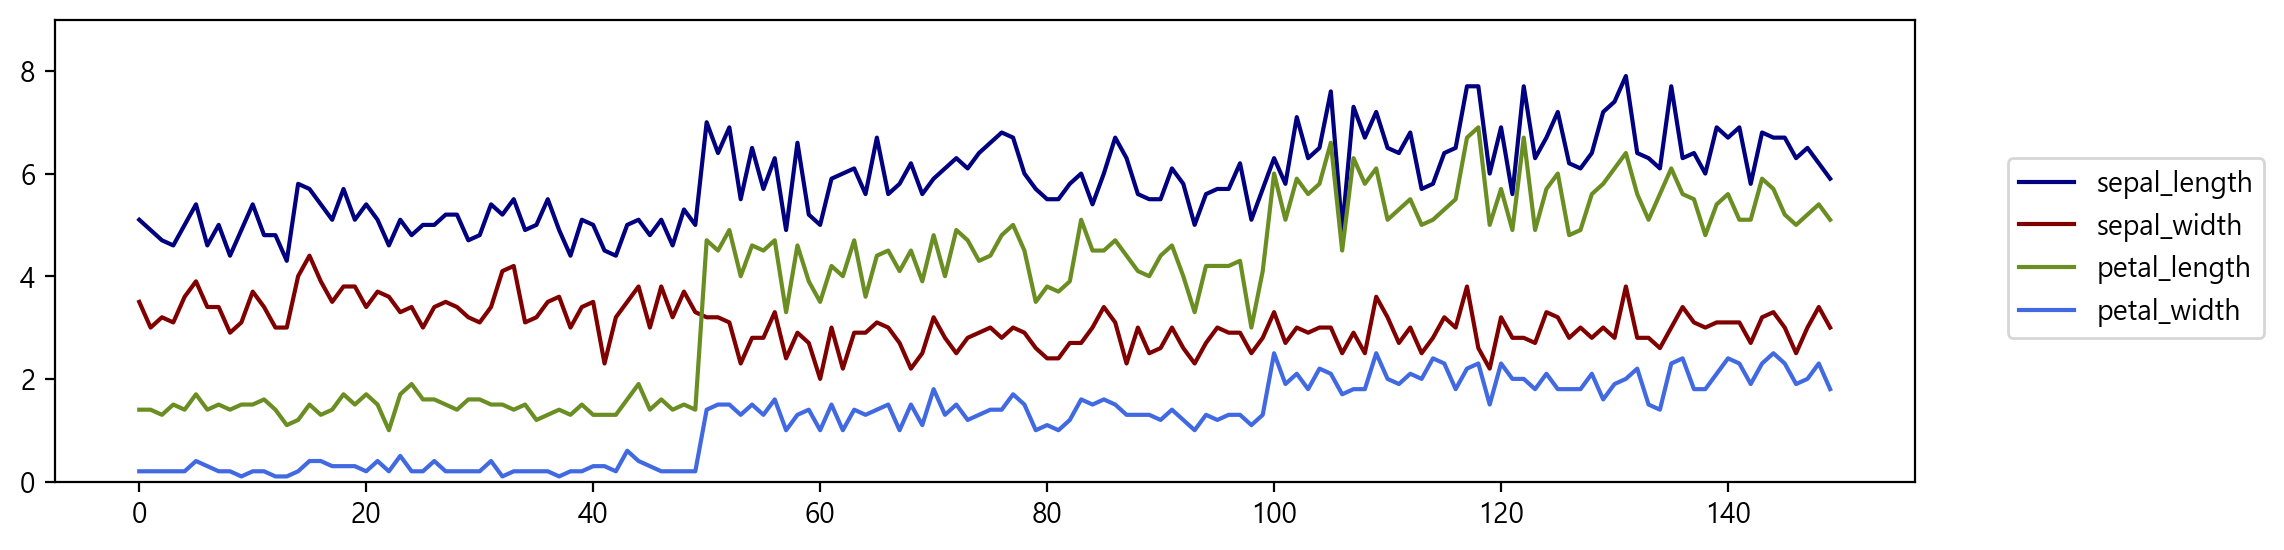

In [111]:
# 권장하는 방식 df. plot
iris.plot(kind='line', figsize=(12,3), color = ['navy','maroon','olivedrab','royalblue'], ylim=[0,9])
plt.legend(iris.columns[:-1],bbox_to_anchor=(1.05, 0.7), loc=2, borderaxespad=0.)

* [box-and-whisker plot](https://ko.wikipedia.org/wiki/상자_수염_그림)
* [colormap](https://matplotlib.org/stable/tutorials/colors/colormaps.html)

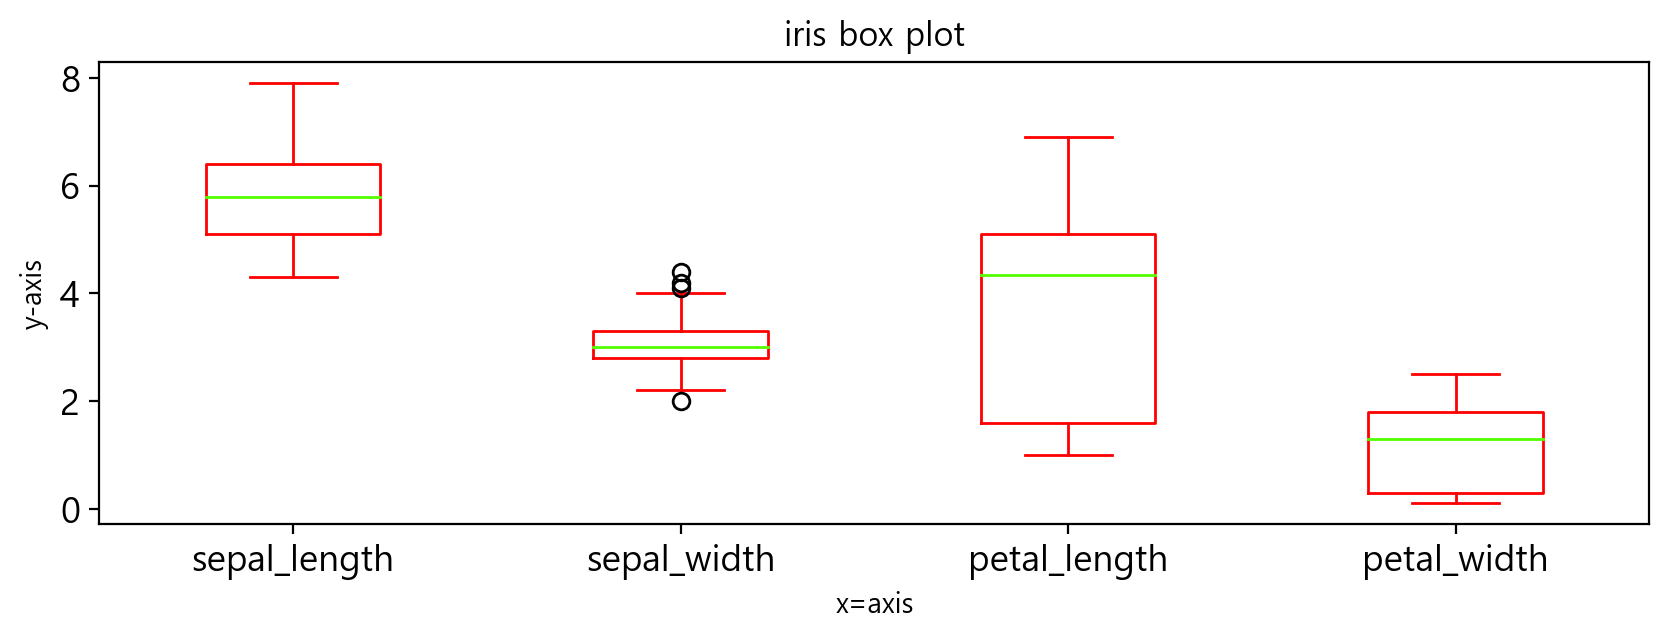

In [122]:
# df. plot의 커스터마이징
iris.plot(kind='box',
         colormap='prism',
         title='iris box plot',
         ylabel='y-axis', xlabel='x=axis',
         fontsize=13)
plt.show()

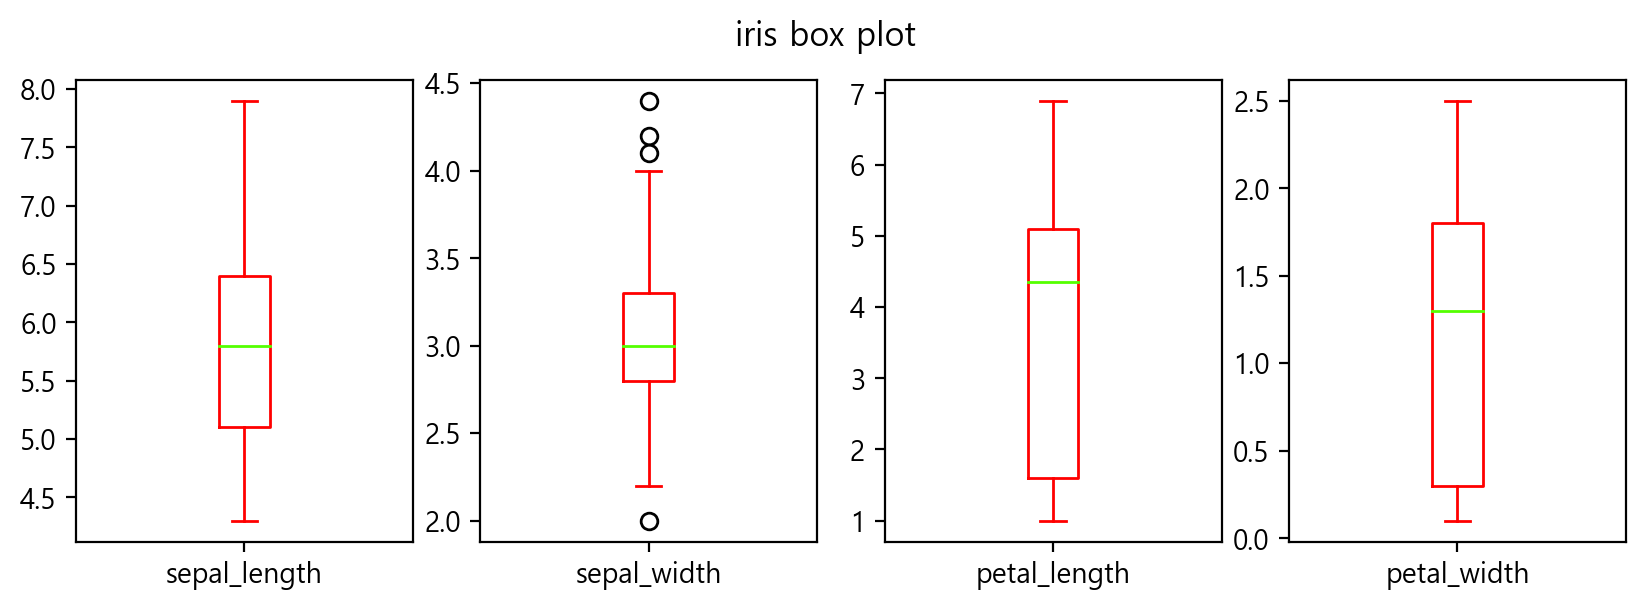

In [124]:
# df. plot의 subplot 생성
iris.plot(kind='box',
         colormap='prism',
         title='iris box plot',
         subplots=True)
plt.show()

In [126]:
iris.corr(numeric_only=True)

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


<Axes: xlabel='petal_length', ylabel='petal_width'>

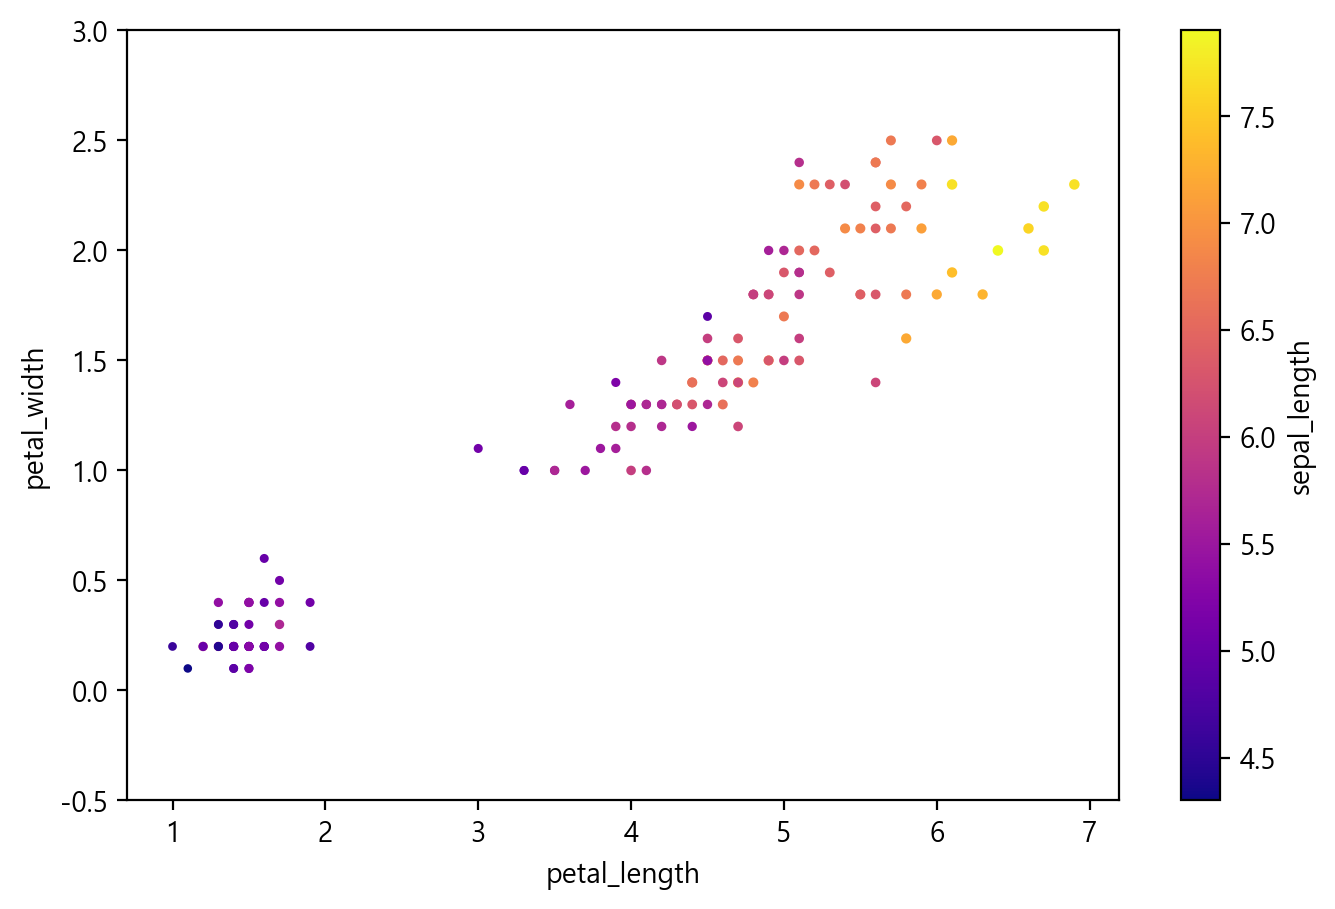

In [138]:
iris.plot(kind='scatter', x='petal_length', y='petal_width', ylim=[-0.5,3], figsize=(8,5),
         s='sepal_length', # scatter size
         c='sepal_length', # scatter color
         colormap='plasma'
         )

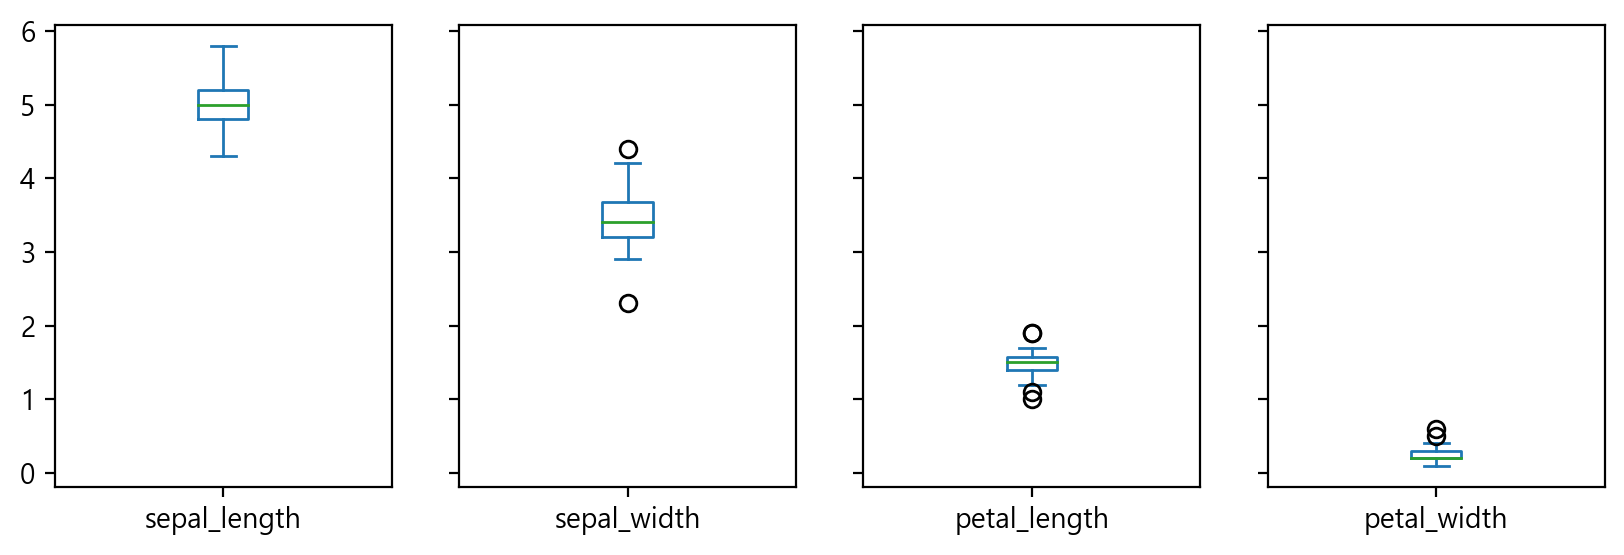

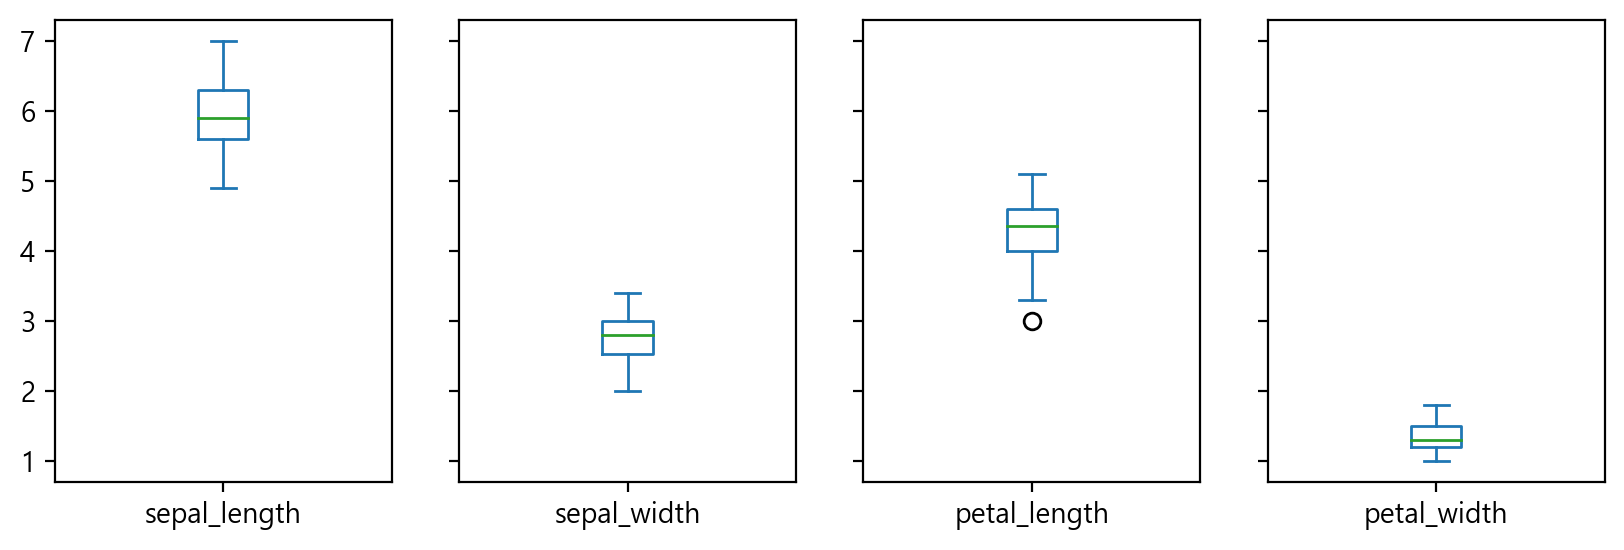

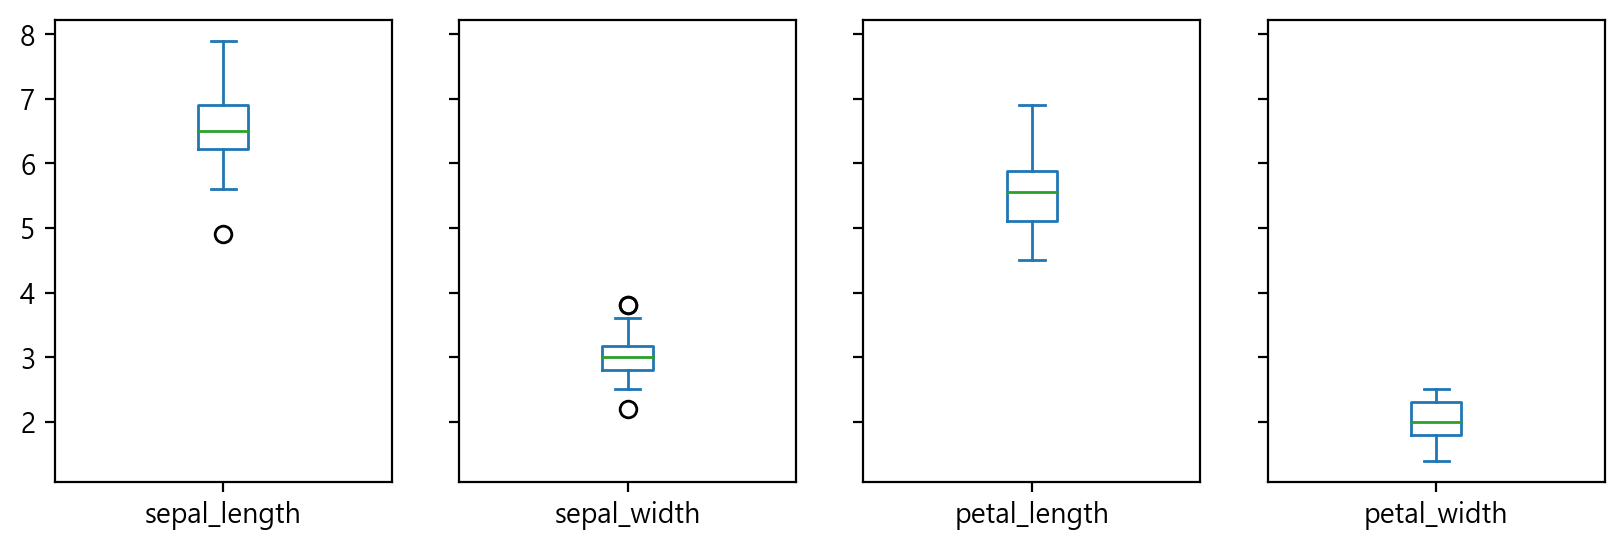

In [147]:
# iris 종 별 boxplot
iris.groupby('species').plot(kind='box', subplots=True, sharey=True, 
                             figsize=(10,3))
plt.show()

### 4) plt.scatter()
- x, y축이 숫자형 데이터여야함

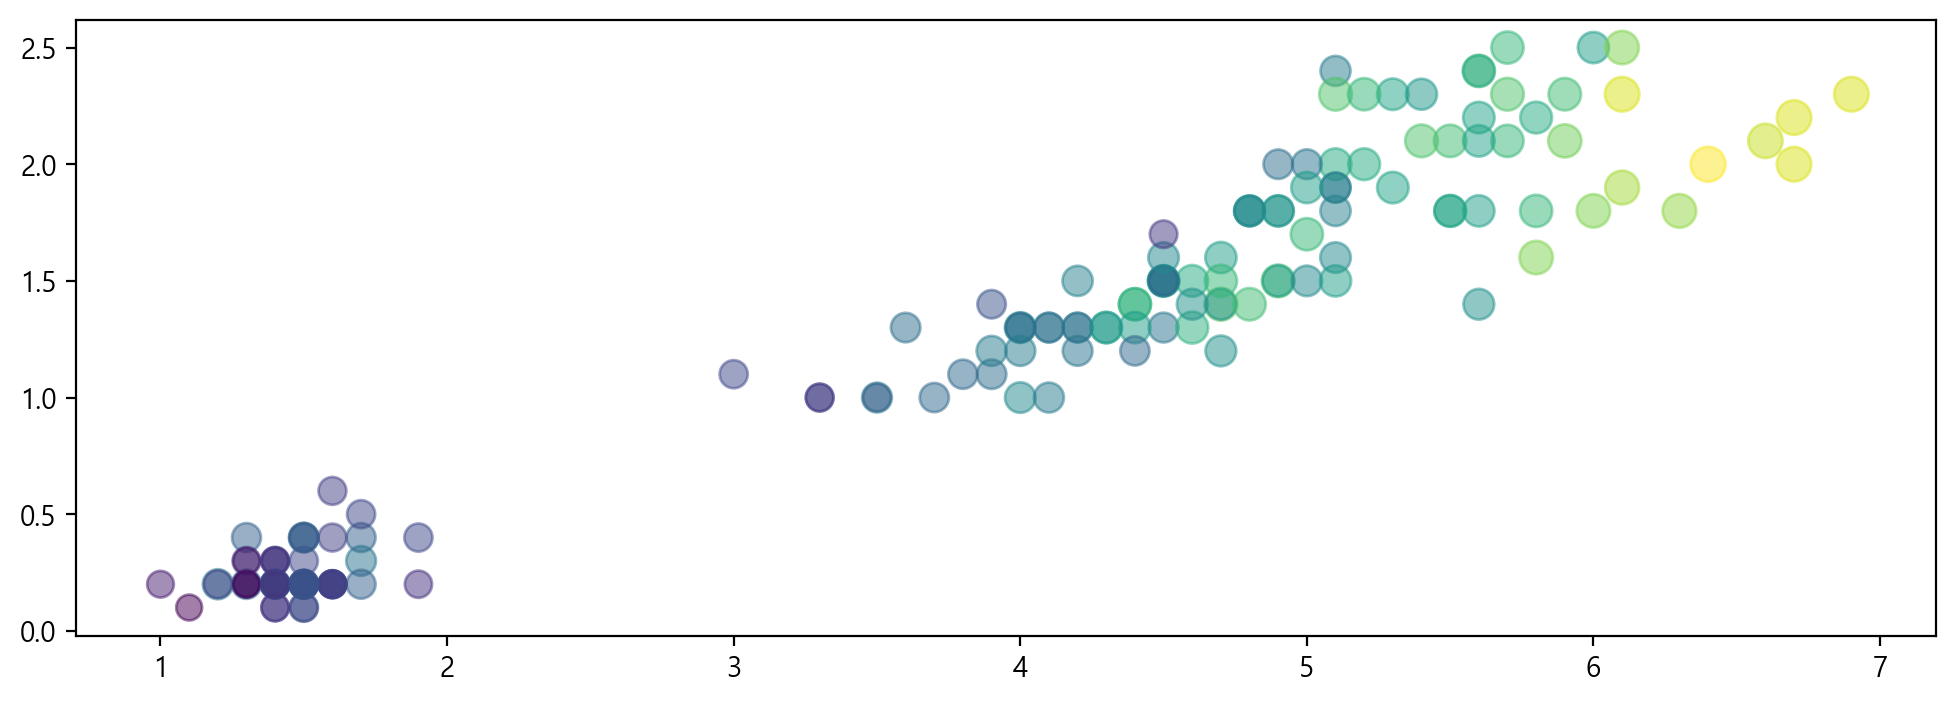

In [153]:
plt.figure(figsize=(12,4))
plt.scatter(x=iris.petal_length, y=iris.petal_width,
           s=iris.sepal_length*20,
           c=iris.sepal_length*20,
           alpha=0.5) # 투명도 (투명 0 ~ 불투명 1)

## 1.5 그 외 그래프 그리기
### 1) boxplot(), violinplot()
- boxplot : 요약 통계량 5가지(최소값, Q1, 중위수, Q3, 최대값)와 이상치(Outlier)
- violinplot : 커널 밀도 추정(KDE, Kernel Density Estimation) 곡선, 분포 형태를 시각적으로 확인 가능

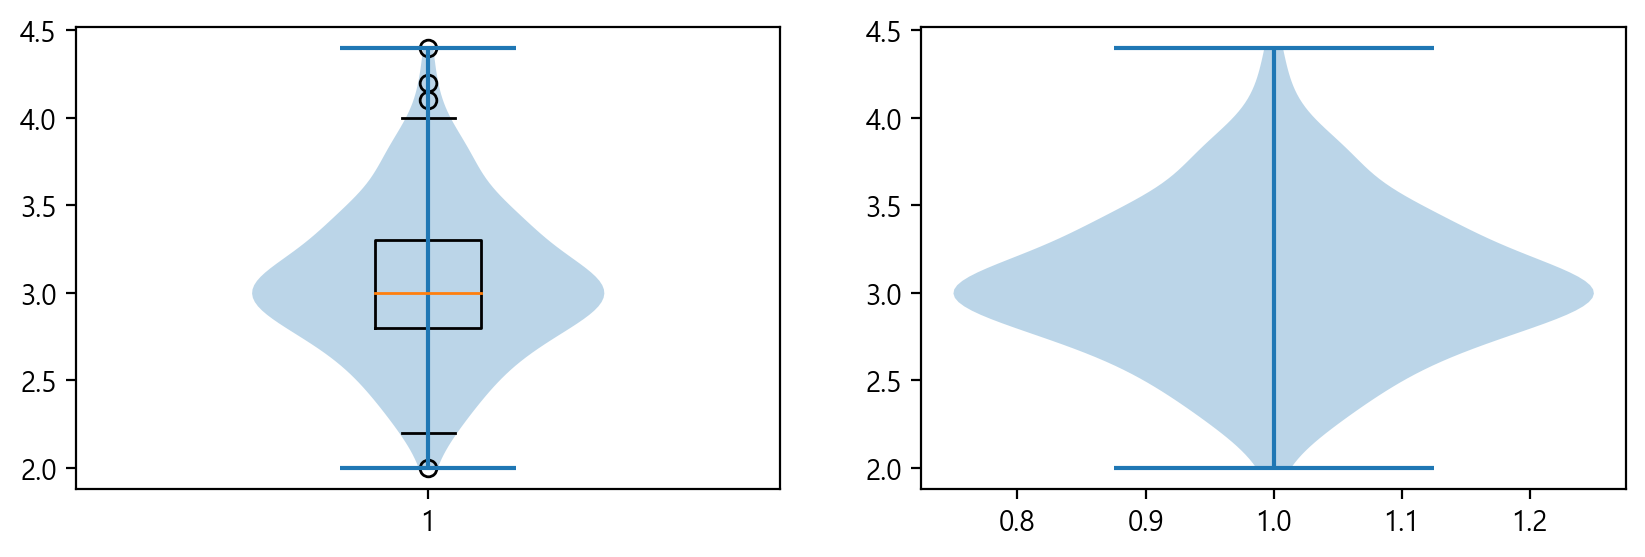

In [168]:
fig, axes = plt.subplots(1, 2)
axes[0].boxplot(iris.sepal_width)
axes[0].violinplot(iris.sepal_width) # box와 violin을 함께 표현

#sns.violinplot(y=iris.sepal_width, ax=axes[1])
axes[1].violinplot(iris.sepal_width)
plt.show()

### 2) bar(), barh()

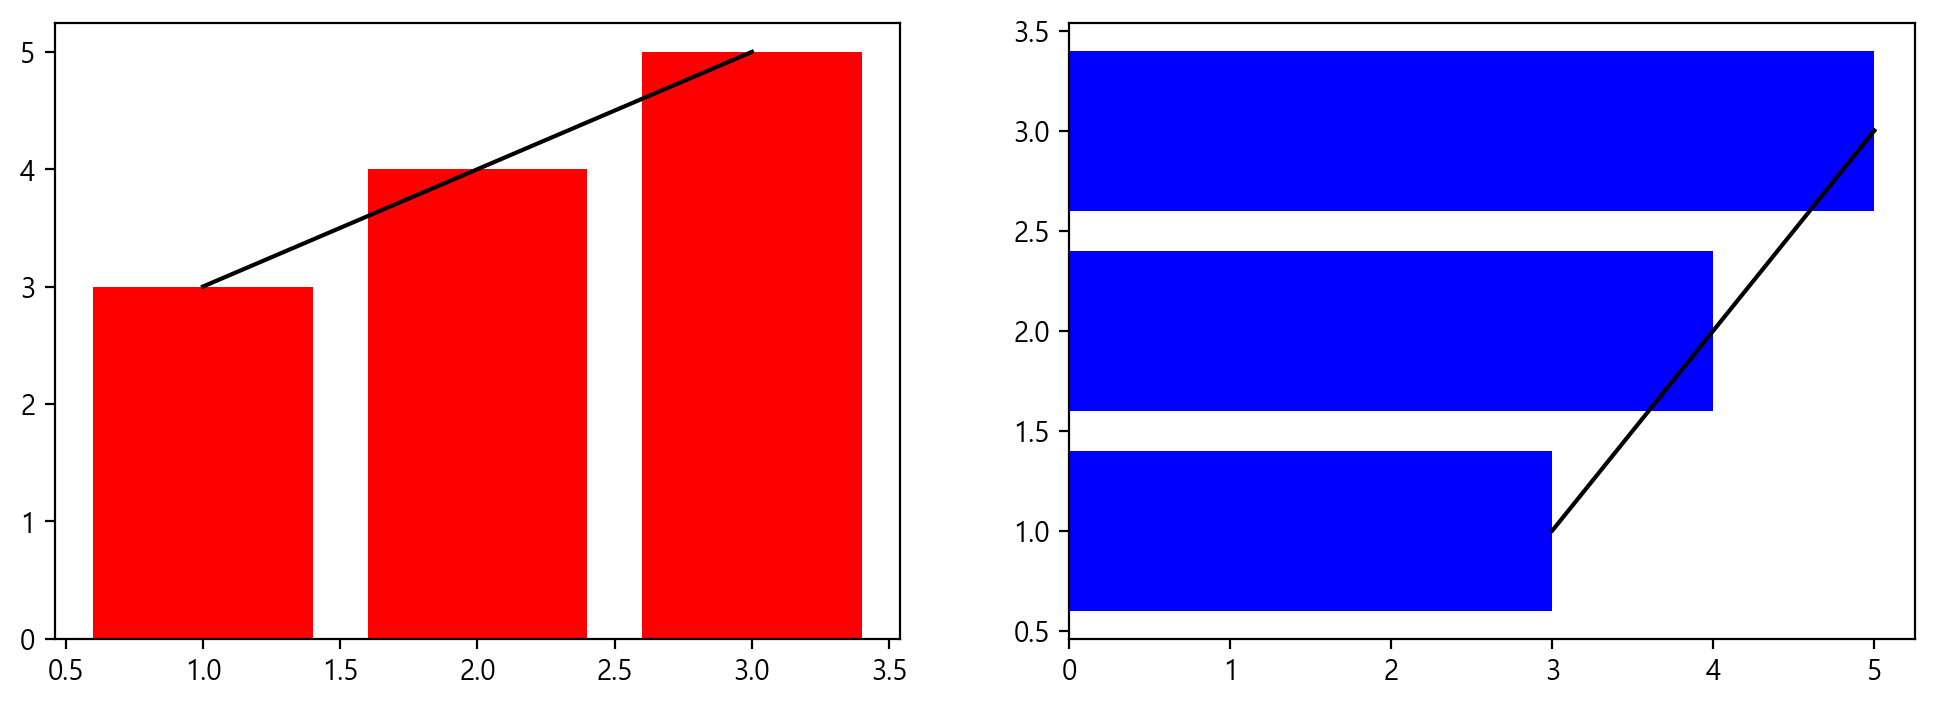

In [181]:
x = [1,2,3]
y = [3,4,5]
fig, axes = plt.subplots(1, 2, figsize = (12,4))
axes[0].bar(x, y, color='r')
axes[0].plot(x, y, c='k')
axes[1].barh(x, y, color='b') # 가로축이 y, 세로축이 x
axes[1].plot(y, x, c='k')

### 3) hist()
- 히스토그램
- 도수분포표의 그래프화

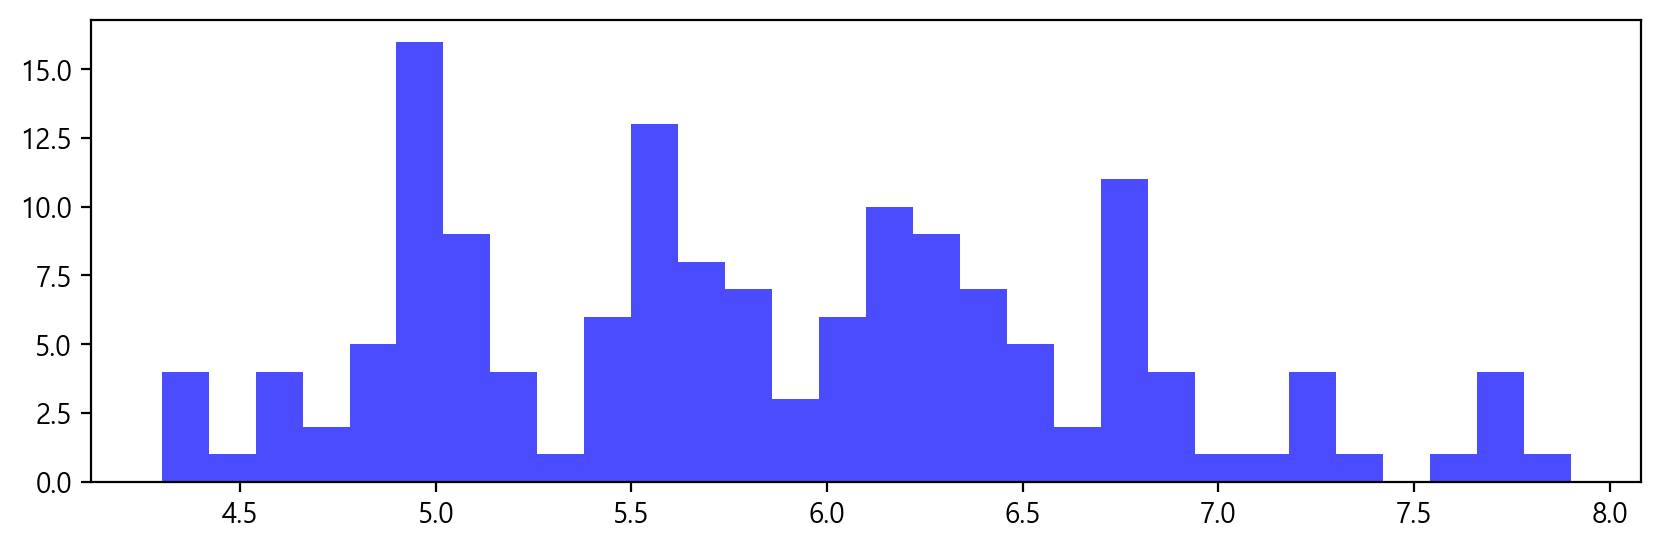

In [190]:
plt.hist(
    iris.sepal_length,
    bins=30, # 30개 구간으로 세분화
#    orientation='horizontal', # Y축이 값(Sepal Length), X축이 빈도수(Count)
    color='blue', # 막대 색상
#    edgecolor='black', # 막대 테두리선 (구분감이 훨씬 좋아짐)
    alpha=0.7, # 투명도
#    cumulative=True # 누적 histogram
    )
plt.show()

### 4) axvline(), axhline(), fill(), fill_between()

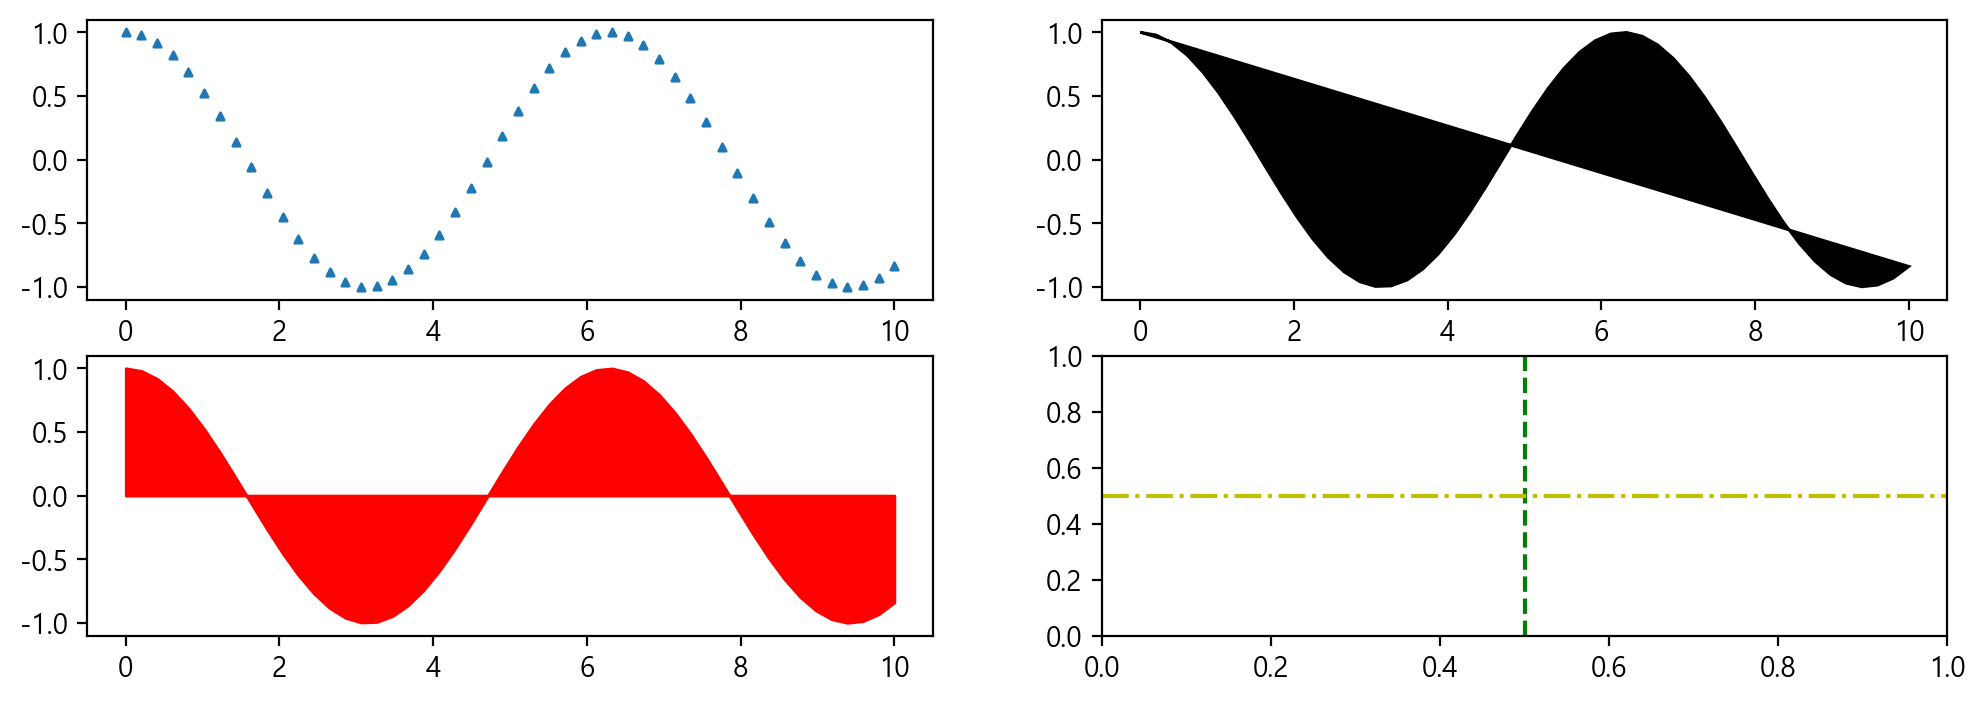

In [206]:
x = np.linspace(0, 10) # 기본값 : 50개 생성
y = np.cos(x)
fig, axes = plt.subplots(2, 2, figsize=(12,4))
axes[0,0].scatter(x, y, s=7, marker='^')
axes[0,1].fill(x, y, c='k')
axes[1,0].fill_between(x, y, color='r')
axes[1,1].axvline(0.5, c='g', linestyle='--')
axes[1,1].axhline(0.5, c='y', linestyle='-.')

### 5) pie

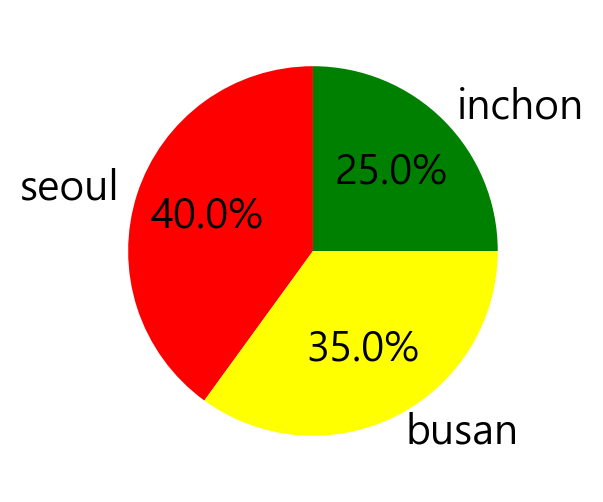

In [213]:
cnt = [40, 35, 25]
labels = ['seoul', 'busan', 'inchon']
colors = ['red', 'yellow', 'green']
plt.pie(cnt, startangle=90, 
        autopct="%.1f%%", 
        textprops={'fontsize':15}, 
        labels=labels,
        colors=colors)
plt.show()

## 1.6 그래프 커스터마이징

### 1) linestyle, linewidth, color, marker, ...

### 2) text(), annotate()
- [axes docs](https://matplotlib.org/stable/api/axes_api.html#text%20and%20annotations)

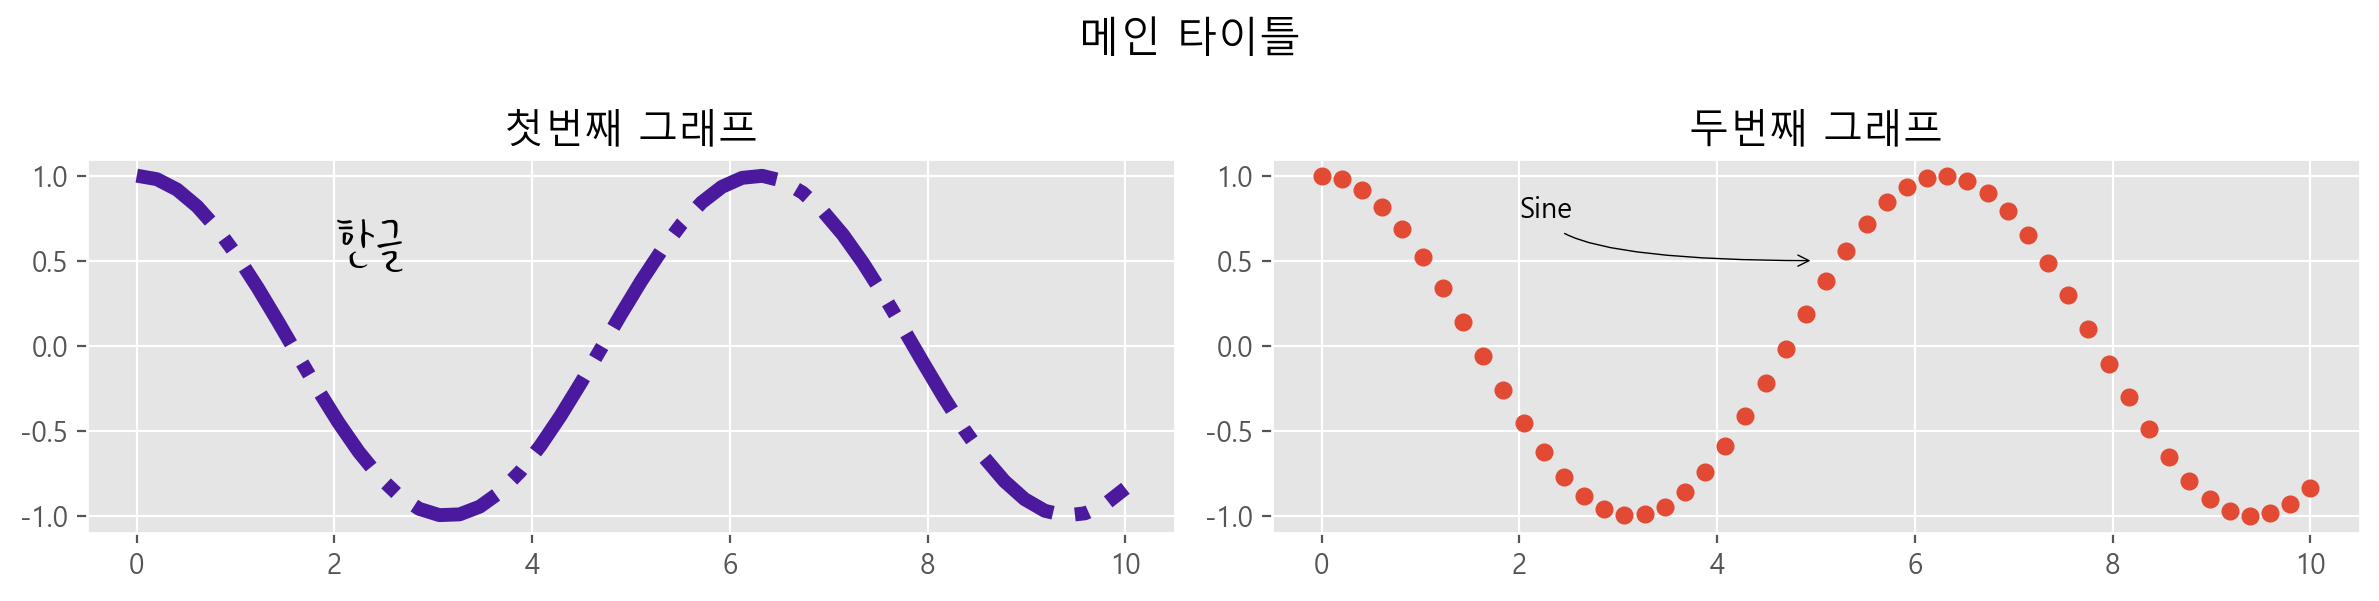

In [252]:
x = np.linspace(0, 10)
y = np.cos(x)

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

axes[0].plot(x, y, linewidth=5, linestyle='-.', color='#4a199e')
axes[0].set_title('첫번째 그래프')

# 텍스트 추가
axes[0].text(2, 0.5, # 텍스트가 위치할 좌표
            '한글', # 텍스트 내용
            fontsize=20,
            fontproperties=font_prop)

axes[1].scatter(x, y, marker='o')

# annotate 추가
axes[1].annotate('Sine', xytext=(2, 0.75), # 텍스트가 위치할 좌표
                xy=(5,0.5), # 화살표가 가리킬 좌표
                arrowprops = dict(arrowstyle='->', # 화살표 끝 모양
                                 connectionstyle='angle3',
                                 color='k')) # angle, angle3, ...

axes[1].set_title('두번째 그래프')

plt.suptitle('메인 타이틀', fontsize=15)
plt.tight_layout()
plt.show()

### 3) 수학기호

- [mathtext](https://matplotlib.org/users/mathtext.html)

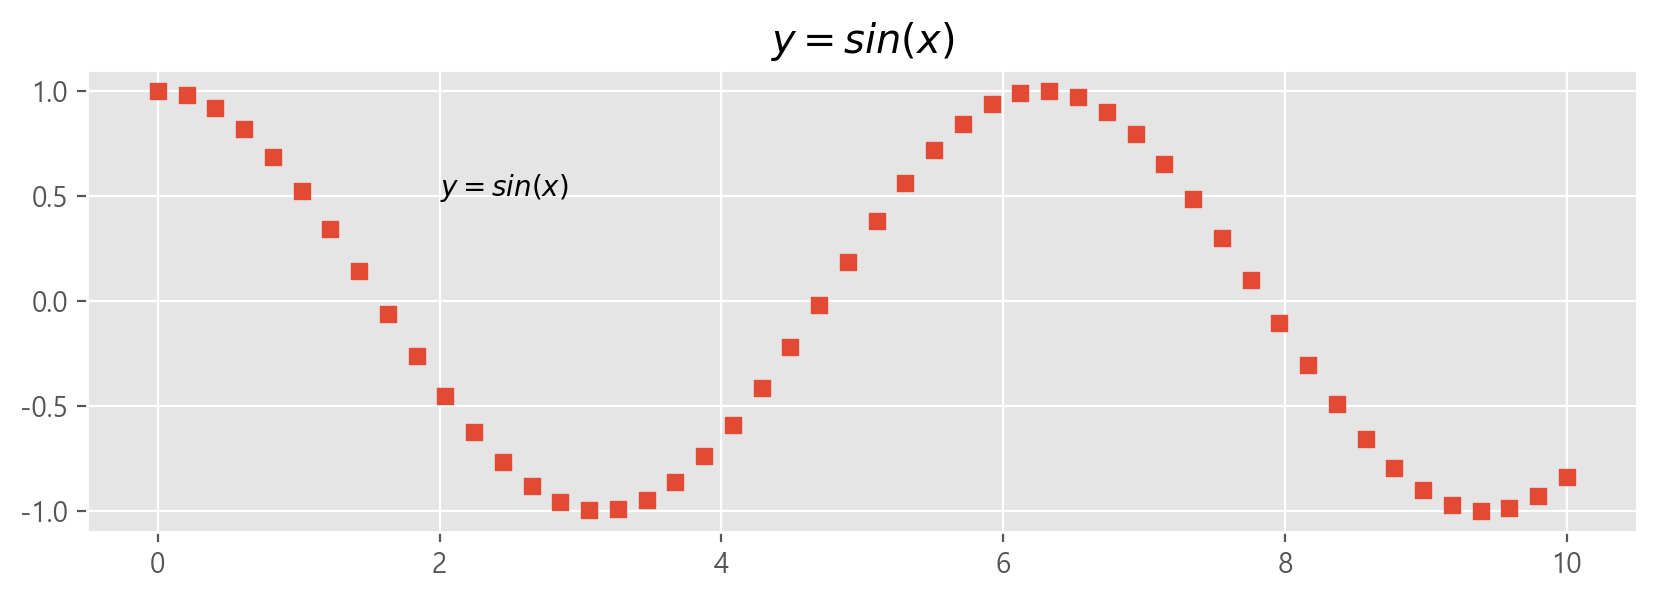

In [266]:
plt.scatter(x, y, marker='s')
plt.title(r'$y=sin(x)$')
plt.text(2, 0.5, '$y=sin(x)$', fontsize=10)
plt.show()

### 4) 축과 눈금
- [axis api](https://matplotlib.org/3.1.0/api/axis_api.html)

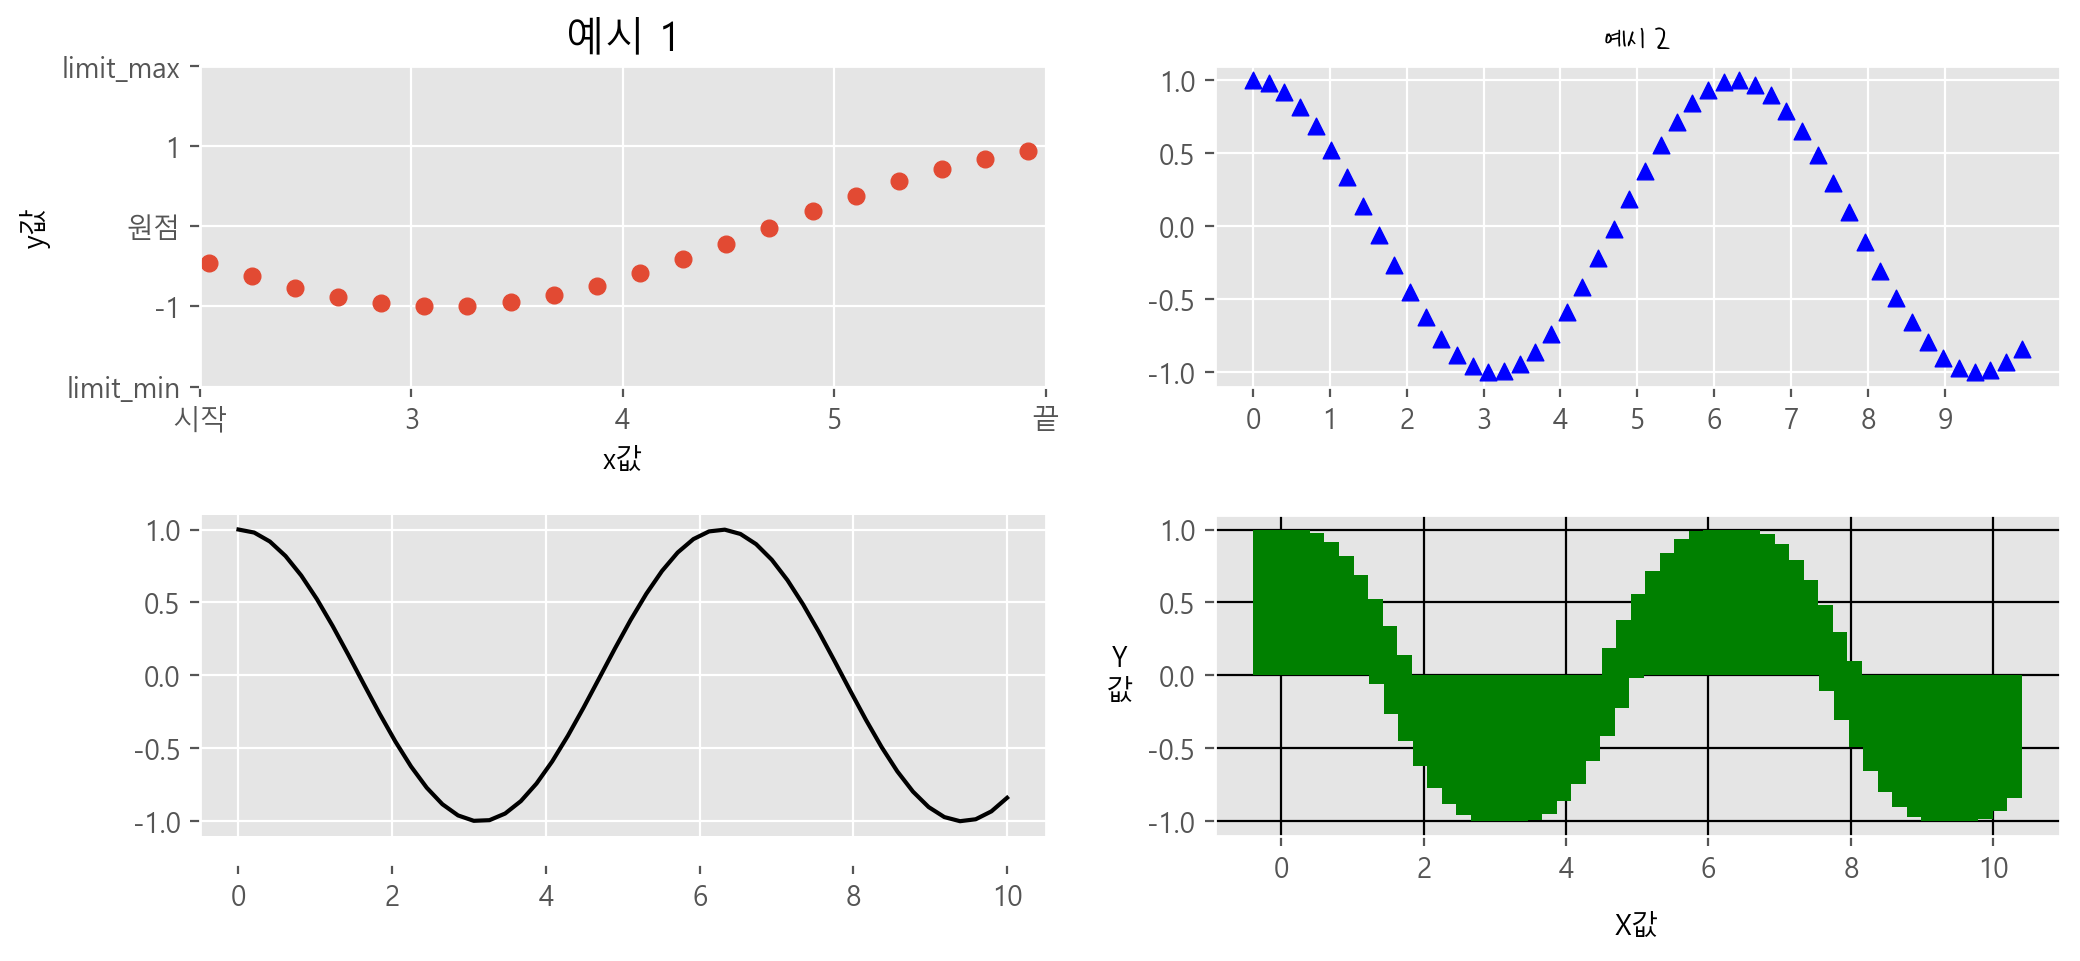

In [305]:
x = np.linspace(0, 10)
y = np.cos(x)

fig, axes = plt.subplots(2, 2, figsize=(12,5))
#subplot 사이의 여백 조정
plt.subplots_adjust(hspace=0.4, wspace=0.2) # haspace : 위아래 여백, wspace : 좌우 여백

axes[0,0].scatter(x, y)
axes[0,0].set(title='예시 1',
             ylabel='y값',
             xlabel='x값',
             ylim=[-2,2],
             xlim=[2,6],
             yticks=[-2,-1,0,1,2], # y축 눈금 
             yticklabels=['limit_min', -1, '원점',1,'limit_max'], # y축 눈금의 라벨
             xticks=[2,3,4,5,6],
             xticklabels=['시작',3,4,5,'끝'])

axes[0,1].scatter(x, y, c='b', marker='^')
axes[0,1].set_title('예시 2', fontsize=20, fontproperties=font_prop)
axes[0,1].set_xticks(range(0,10,1))

axes[1,0].plot(x, y, c='k')
axes[1,0].spines['top'].set_visible(False) # 그래프 시작점의 여백
axes[1,0].spines['bottom'].set_position(('outward', 10)) # 10pt만큼 바깥으로 이동

axes[1,1].bar(x, y, color='g')
axes[1,1].grid(True, color='k', linestyle='-')
plt.ylabel('Y\n값', rotation=0, labelpad=10, va='center')
plt.xlabel('X값', labelpad=10)

plt.show()

### 5) 축 공유

In [310]:
import numpy as np
x = np.arange(0, 10)
y1 = 0.5*x**2
y2 = -y1

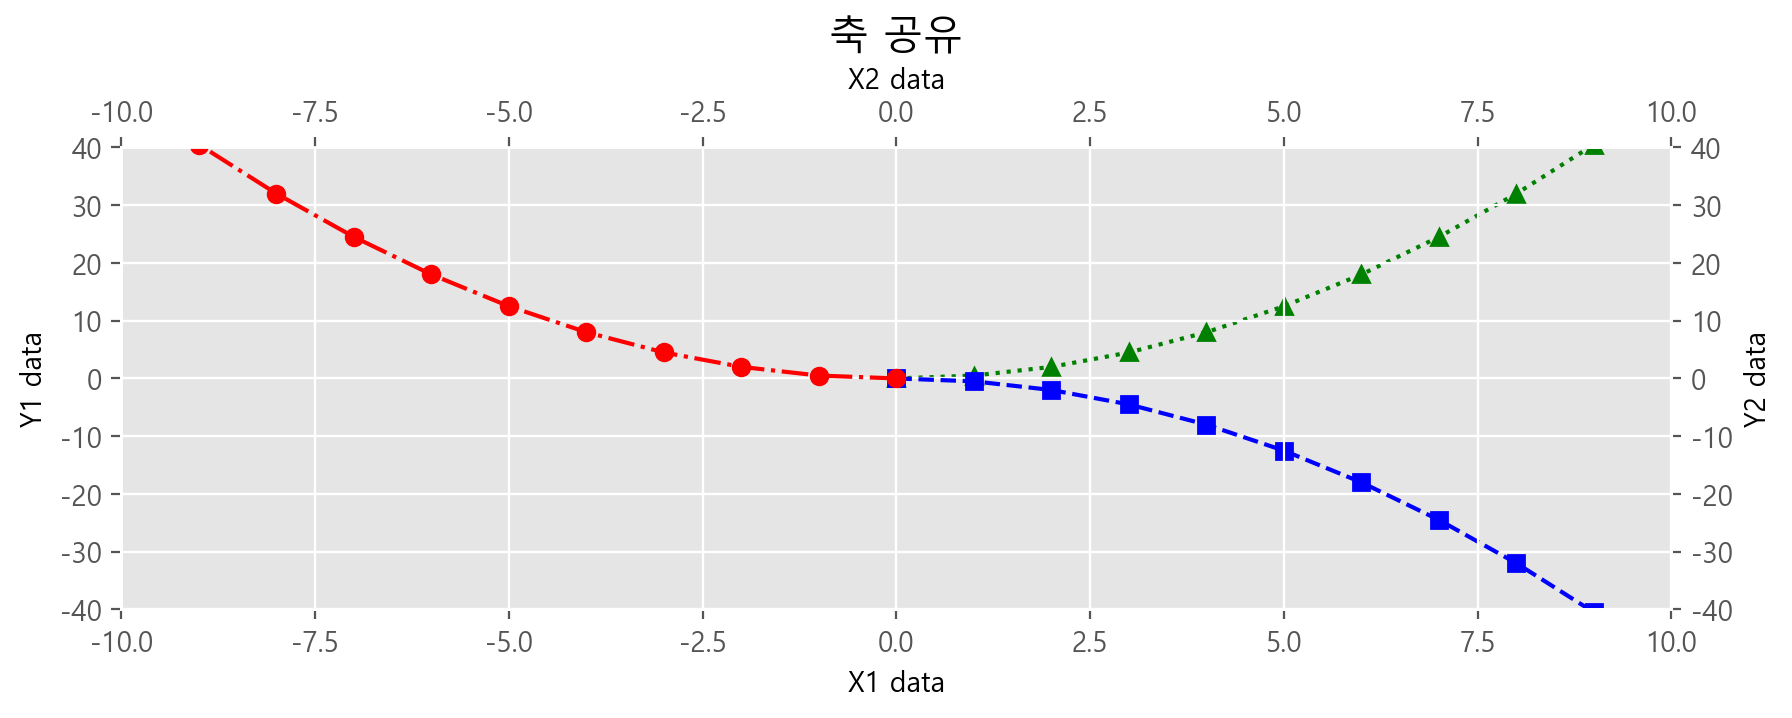

In [323]:
fig, ax1 = plt.subplots(figsize=(10,3))
ax1.plot(x,y1,'g^:')
ax1.set(title='축 공유', 
        xlabel='X1 data',
        ylabel='Y1 data',
        xlim=[-10,10],
        ylim=[-40,40])

ax2 = ax1.twinx() # ax1과 x축을 공유함
ax2.plot(x,y2, 'bs--')
ax2.set_ylabel('Y2 data')
ax2.set(xlim=[-10,10],
        ylim=[-40,40])

ax3 = ax1.twiny()
ax3.plot(-x, y1, 'ro-.')
ax3.set_xlabel('X2 data')
ax3.set(xlim=[-10,10],
        ylim=[-40,40])
plt.show()

### 6) 범례 표시

- [move legend](https://stackoverflow.com/questions/30490740/move-legend-outside-figure-in-seaborn-tsplot)

### 7) 플롯 스타일 지정
- 플롯 스타일 지정 시 플롯의 기존 설정값이 초기화
    * plt.rc('font', family='Malgun Gothic')
    * plt.rc('axes', unicode_minus=False)

In [324]:
plt.style.use('ggplot')
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

In [325]:
plt.style.use('ggplot')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus']=False

# 2. seaborn
- matplotlib 기반의 고수준 그래픽 라이브러리
- 공식 api [Seaborn](https://seaborn.pydata.org/api.html)

- seaborn으로 그래프를 그리기 위한 단계
    1) 데이터 준비
    2) 미적 속성 설정
    3) 함수로 그래프 그리기(관계형/수치형, 범주형, 쌍관계, 밀도, 회귀, 다중그래프, ...)
    4) 그래프 커스터마이징
    5) 그래프 출력(show) 및 저장(savefig)
    
## 2.1 데이터 준비하기

- iris. titanic

In [326]:
import seaborn as sns

In [327]:
iris = sns.load_dataset('iris')
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [329]:
# survived: 생존 여부 (숫자형)
     # 0 = 사망, 1 = 생존
# pclass: 티켓 등급 (숫자형)
     # 1 = 1등석, 2 = 2등석, 3 = 3등석
# sex: 성별 (male, female)
# age: 나이 (숫자)
# sibsp (Siblings / Spouses): 함께 탑승한 형제·자매 및 배우자 수
# parch (Parents / Children): 함께 탑승한 부모 및 자녀 수
# fare: 탑승 요금 (숫자)
# embarked: 탑승한 승선 항구의 앞글자 (약어)
     # C = Cherbourg (쉘부르), Q = Queenstown (퀸즈타운), S = Southampton (사우샘프턴)
# class: pclass를 문자열 표현으로 변환한 값 (First, Second, Third)  
# who: 승객 구분 (man = 성인 남성, woman = 성인 여성, child = 아이)  
# adult_male: 성인 남성 여부 (True / False)  
# deck: 객실 구역/층 (A~G 구역, cabin 번호의 첫 글자에서 추출)  
# embark_town: embarked의 풀네임 (Cherbourg, Queenstown, Southampton)  
# alive: survived를 문자열로 변환한 값 (yes / no)  
# alone: 혼자 탑승했는지 여부 (True / False)  
     # sibsp와 parch가 모두 0이면 True

In [328]:
titanic = sns.load_dataset('titanic')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [331]:
titanic.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [332]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


## 2.2 미적 속성 설정하기
- style, context, palette, figsize, ...

### 1) 그래프 스타일 지정
- 주의 : 한글 폰트 설정 코드 재실행 필요

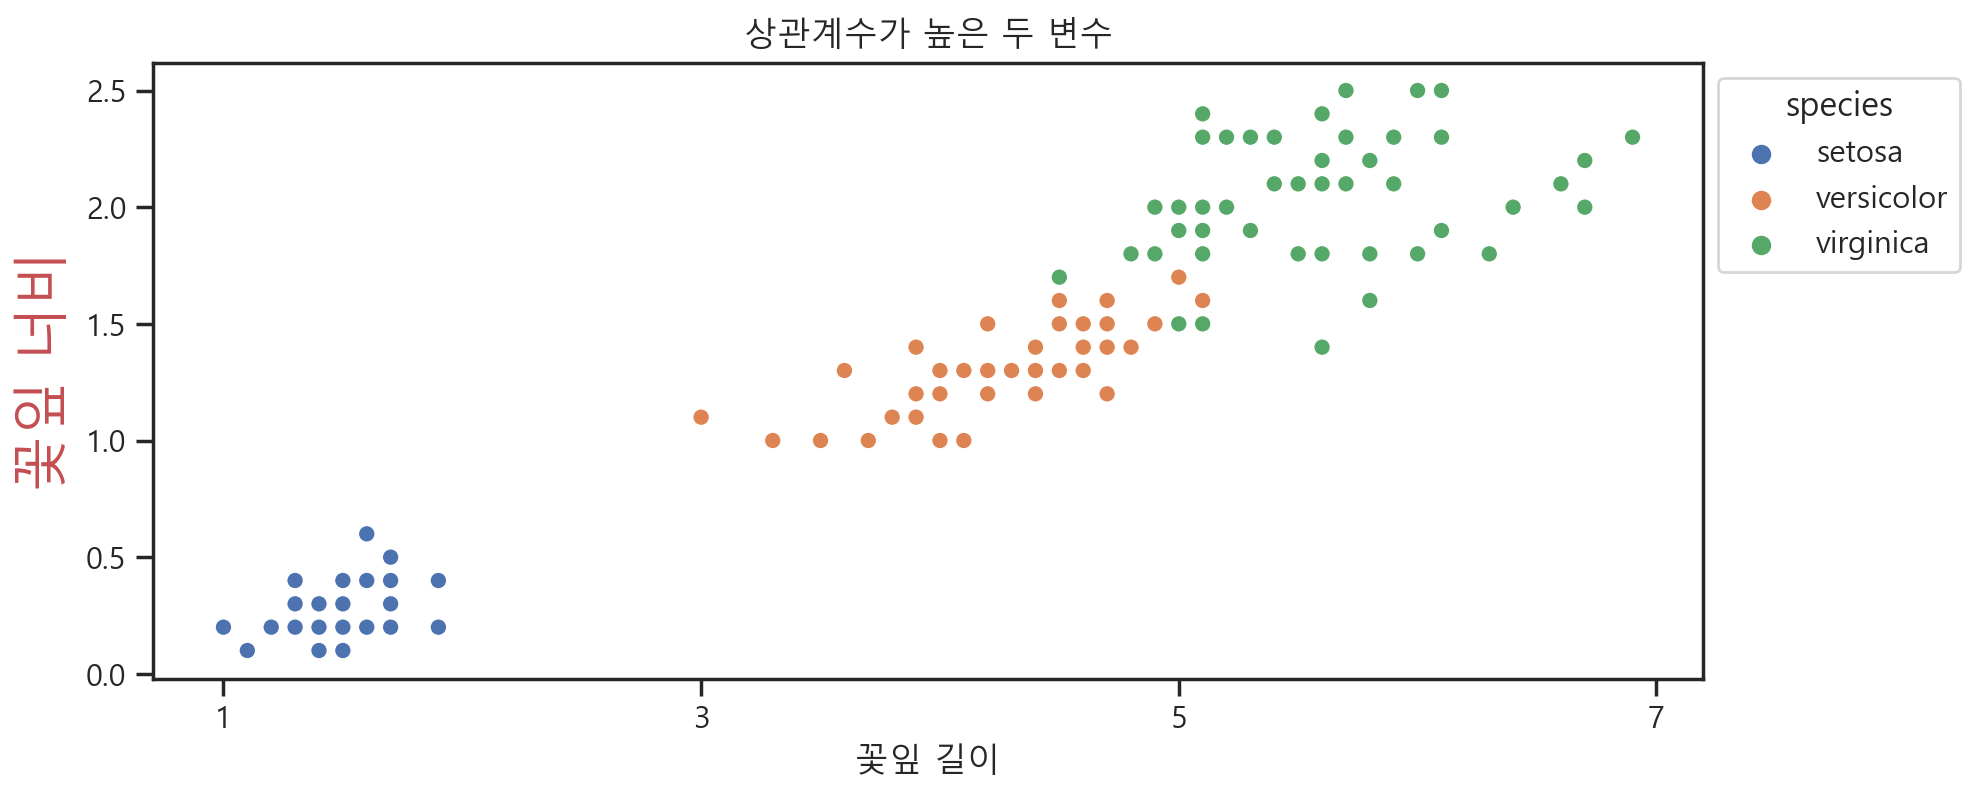

In [353]:
plt.rcParams['figure.figsize'] = (10,4)

sns.set(style='whitegrid') # white, dark, whitegrid, darkgrid, ticks
sns.set_style('ticks')

plt.rc('font',family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

ax = sns.scatterplot(data=iris, x='petal_length', y='petal_width', 
                hue='species') # 기준에 따라 색상을 다르게

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

ax.set(title='상관계수가 높은 두 변수',
      xlabel='꽃잎 길이',
      xticks=[1,3,5,7])

ax.set_ylabel('꽃잎 너비', fontsize= 20, color='r')
plt.show()

### 2) 컨텍스트 지정 (배율)

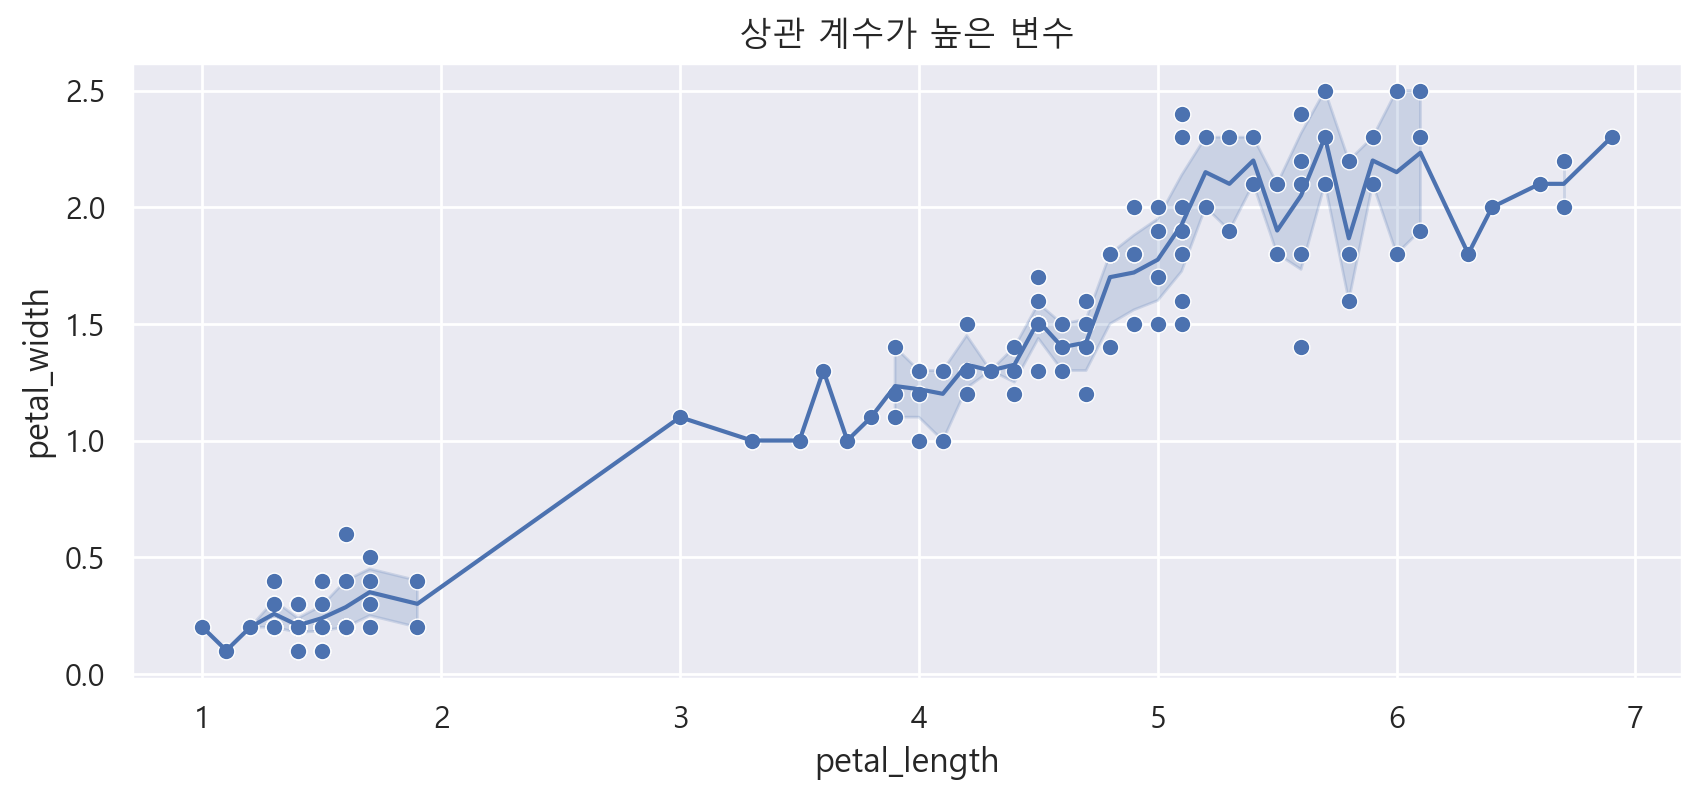

In [357]:
sns.set(context='notebook') # 기본값 : notebook(1.0); paper(0.8), talk(1.3), poster(1.8)
#sns.set_context('notebook')

#set 함수 사용 시 재사용 필요
plt.rc('font',family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

sns.lineplot(data=iris, x='petal_length', y='petal_width')
sns.scatterplot(data=iris, x='petal_length', y='petal_width')
plt.title('상관 계수가 높은 변수')
plt.show()

### 3) 컬러 파레트
- [Seaborn color palettes](https://seaborn.pydata.org/tutorial/color_palettes.html)

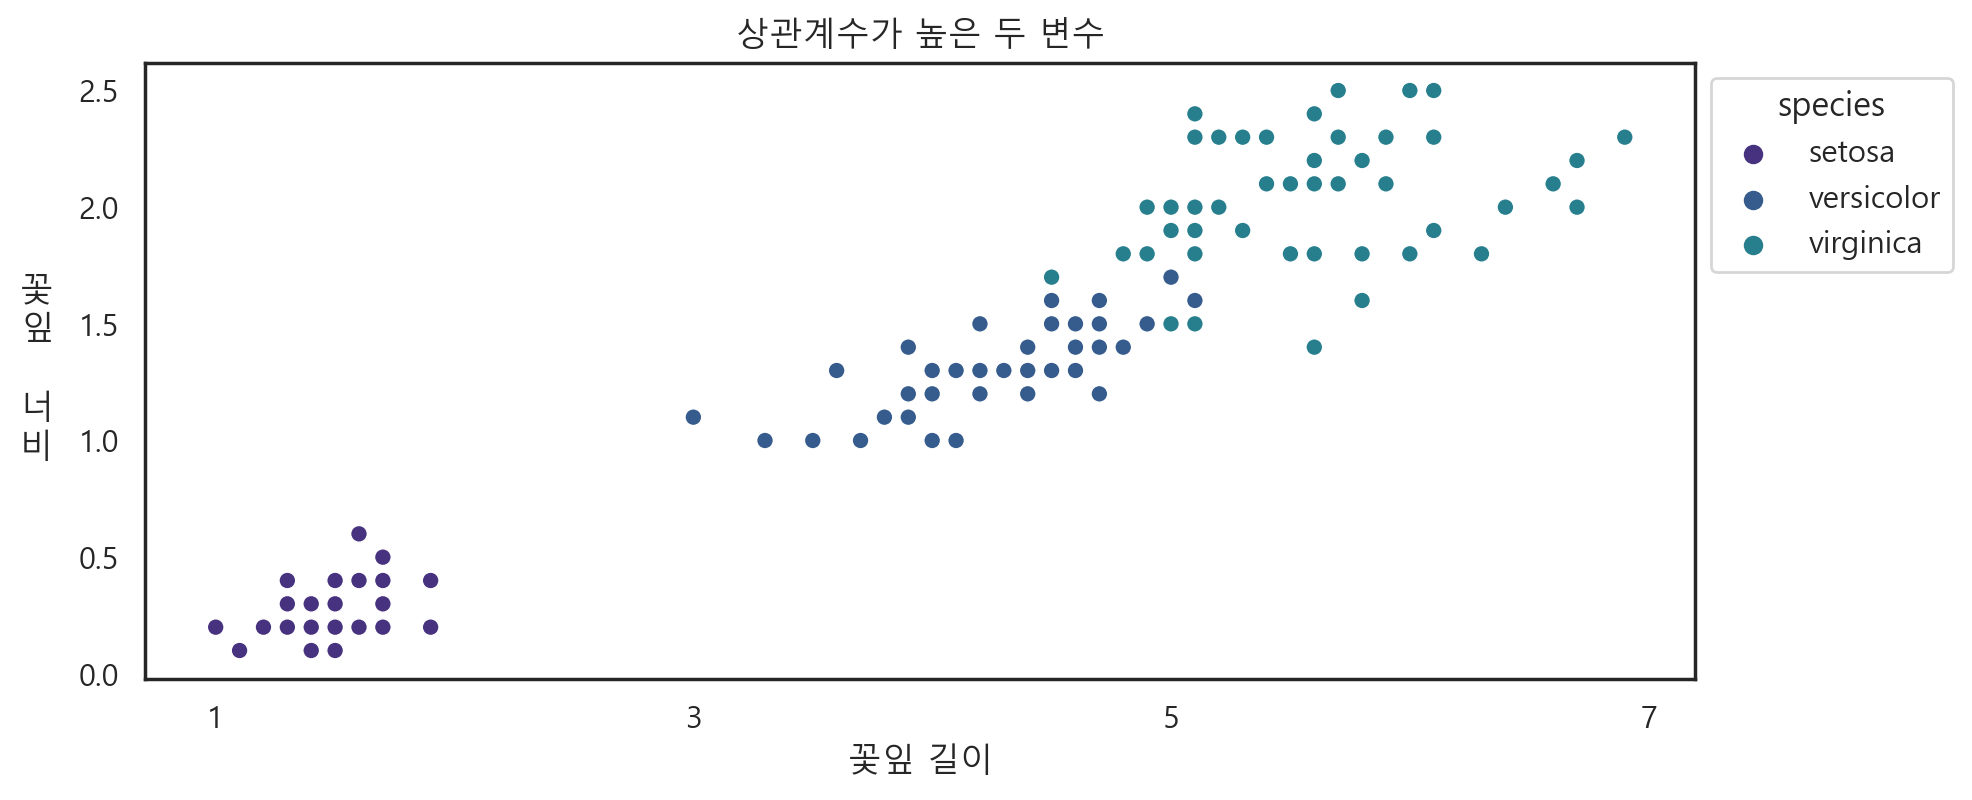

In [363]:
sns.set(palette="viridis", style='white', context='notebook') # 기본 미적 속성

plt.rc('font',family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

ax = sns.scatterplot(data=iris, x='petal_length', y='petal_width', hue='species')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set(title='상관계수가 높은 두 변수', xlabel='꽃잎 길이', xticks=[1,3,5,7])
ax.set_ylabel('꽃\n잎\n\n너\n비', rotation=0, labelpad=15, va='center')
plt.show()

In [371]:
sns.set(style='white',
       context='notebook',
       palette='husl',
       rc = {'figure.figsize':(12,3)})

plt.rc('font',family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

## 2.3 그래프 그리기

### 1) 관계형 그래프
- scatterplot, lineplot, relplot(서브플롯 제공)

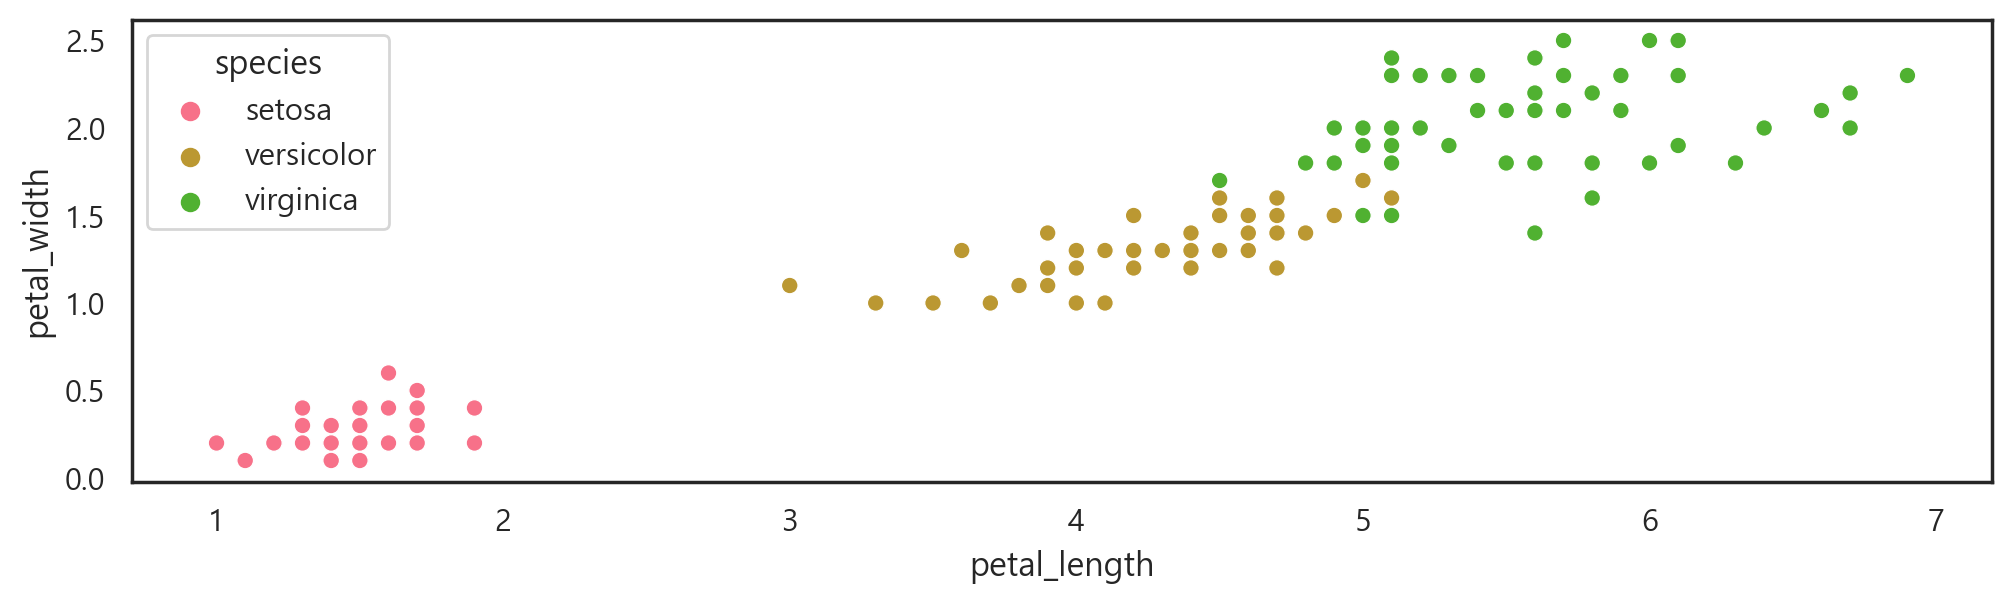

In [373]:
# 종별 다른 색상의 scatterplot
sns.scatterplot(data=iris, x='petal_length', y='petal_width', hue='species')
plt.show()

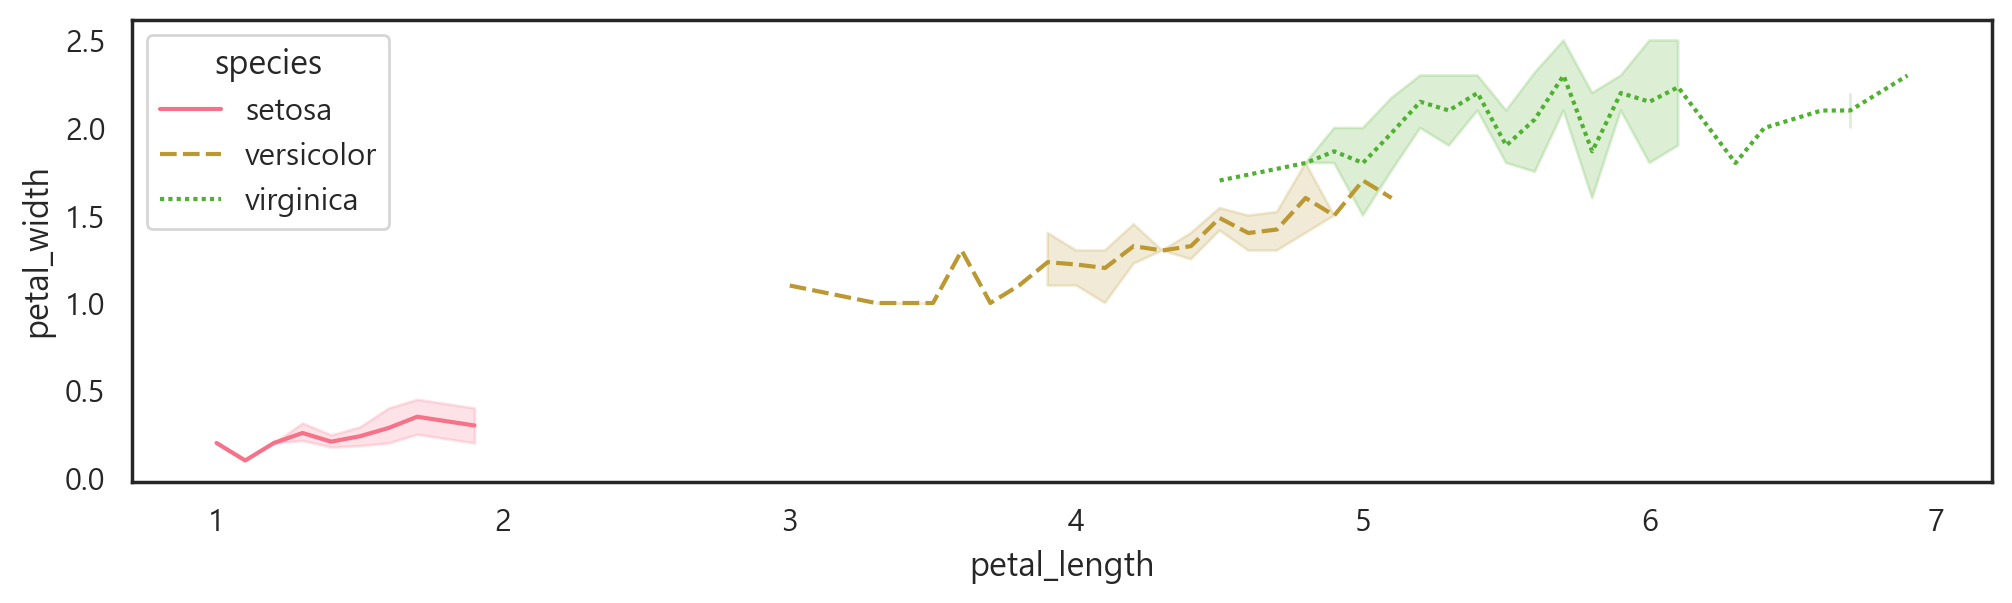

In [379]:
# 종별 다른 색상과 다른 스타일의 lineplot
sns.lineplot(data=iris, x='petal_length', y='petal_width', hue='species', style='species')
plt.show()

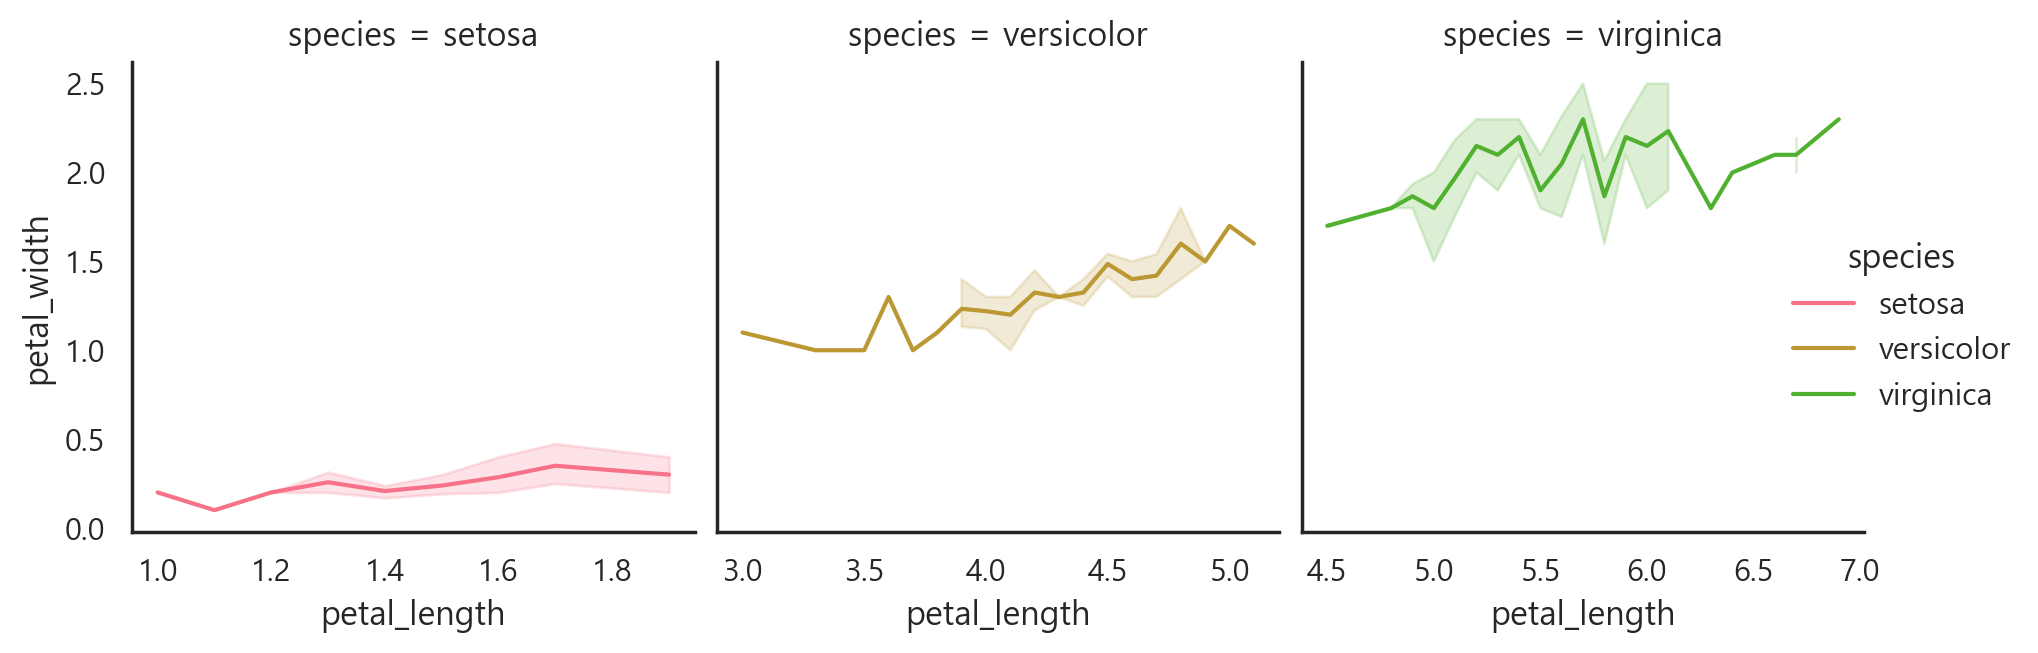

In [387]:
# relplot - line
ax = sns.relplot(data=iris,  x='petal_length', y='petal_width', hue='species', 
            kind='line', # 기본값 : scatter
            col='species', # 'col' 기준으로 분리하여 서브플롯 표현, y축을 공유함
            col_wrap=3, # 한 행에 출력할 서브플롯 개수
            facet_kws={'sharey':True, 'sharex':False} # 축 공유 여부 ; 기본값 : True/True
           )
ax.fig.set_size_inches(10,3) # figsize 적용 불가
plt.show()

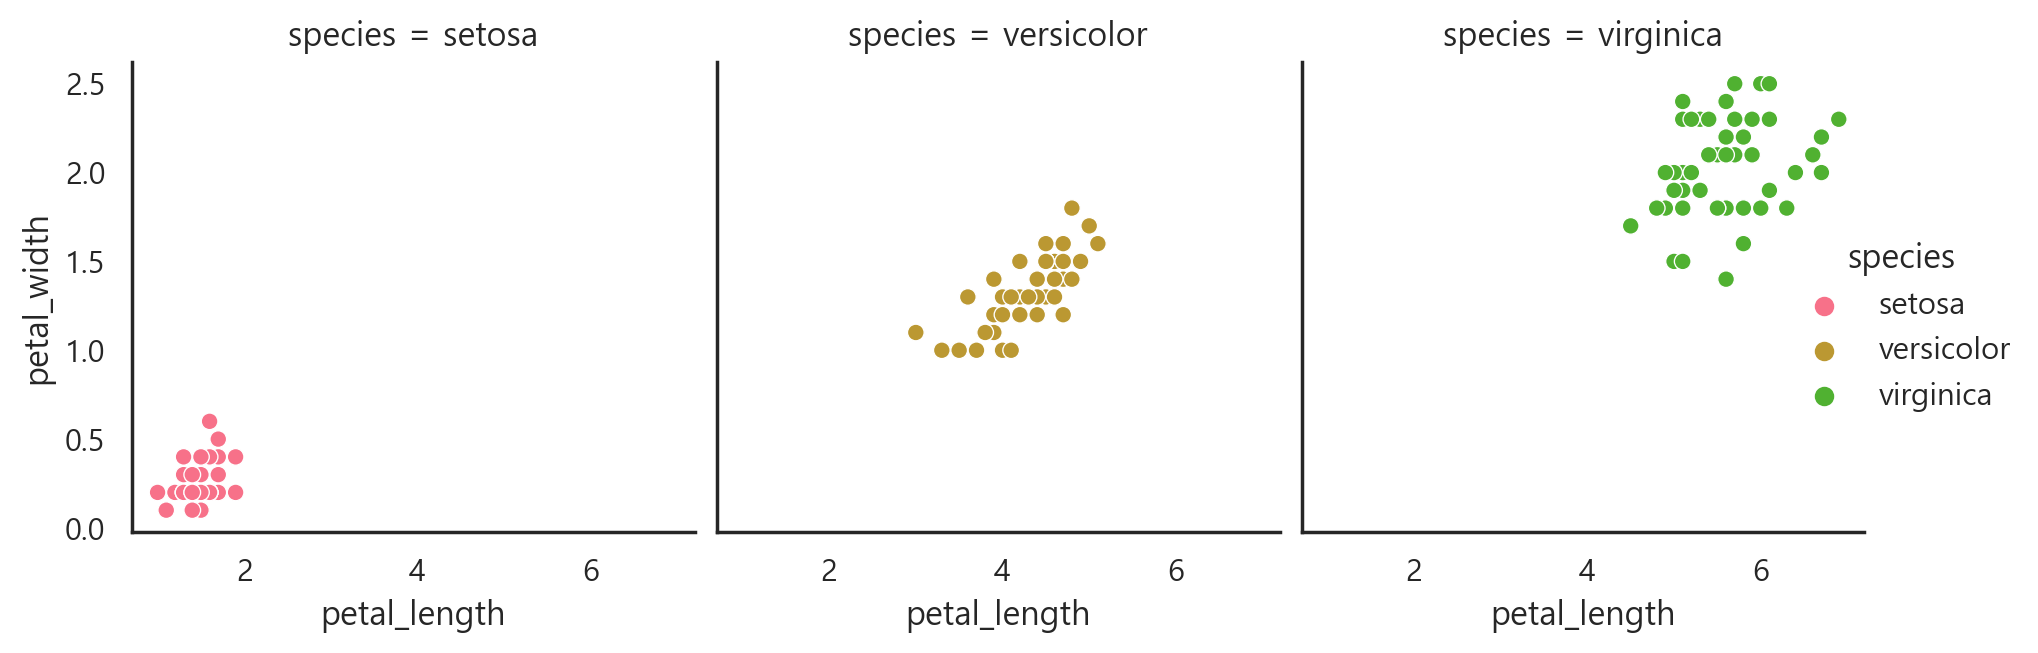

In [388]:
# relplot - scatter
ax = sns.relplot(data=iris,  x='petal_length', y='petal_width', hue='species', 
            kind='scatter', col='species', col_wrap=3)
ax.fig.set_size_inches(10,3)
plt.show()

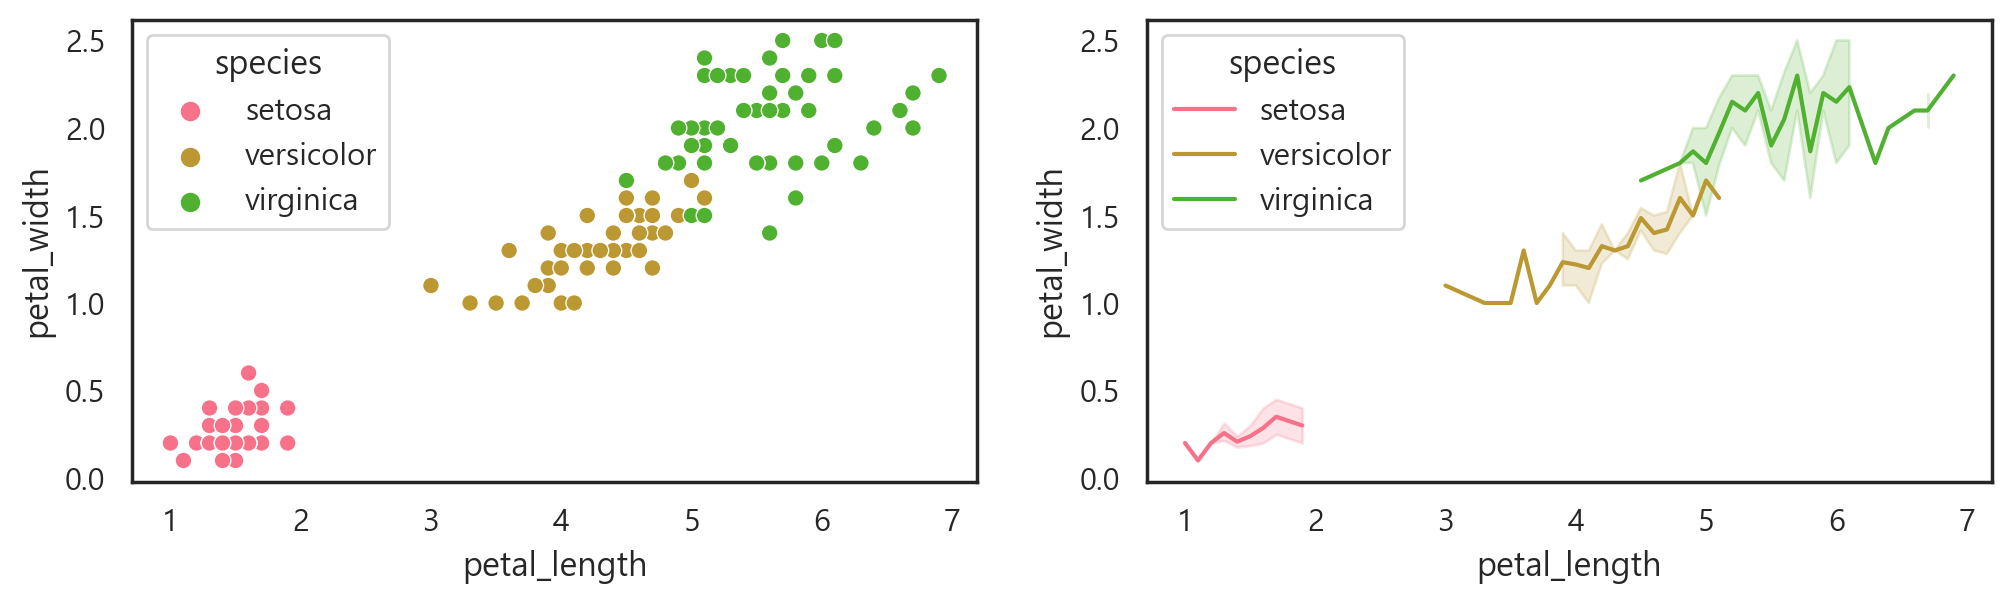

In [394]:
# 서브플롯에서 다른 그래프 구현하기 ; plt와 sns 혼합 필요
fig, ax = plt.subplots(1, 2)
sns.scatterplot(data=iris,  x='petal_length', y='petal_width', hue='species', ax=ax[0])
sns.lineplot(data=iris,  x='petal_length', y='petal_width', hue='species', ax=ax[1])
plt.show()